# Exposure analysis V3 — data-transfer ON vs OFF

V3 sibling of `exposure_analysis.ipynb`. Reads `data/multi_day_v3/` produced
by `multi_day_pipeline_v3.ipynb` and runs:

1. **V3 validation** — sanity-check the new classifier before drawing conclusions:
   - Spread of exits/returns/trips per day, faceted by system and condition.
   - v1 ↔ v3 per-day scatter (should fall close to the identity line, slightly below).
   - Per-track feature distributions split by v3=True/v3=False with threshold lines.
2. **Section A — temporal context.** Daily activity time series per system.
3. **Section B — BASELINE BASELINE.** Mean / SD on BASELINE-only days.
4. **Section C — ON vs OFF.** Boxplots (aligned y-axes per metric), tortuosity
   histograms, Mann-Whitney U tests.
5. **Section K — indicator dashboard.** 4 indicators × 2 systems, with
   Benjamini-Hochberg correction and rank-biserial effect sizes. Vertical
   behaviour (5th indicator) is omitted here because the multi-day v3 pipeline
   doesn't yet persist median-z per track — port from the legacy notebook if needed.

Heavy sections from the legacy notebook (D heatmaps, E spatial, F hourly+BH,
G anchors, H vertical, I IFI detail, J temperature, L headings, M/N
accumulation, O dose-response) are not ported here — they don't depend on v1
vs v3 logic and can be lifted in unchanged once v3 is trusted.


In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


# Paths & treatment schedule
# ---------------------------------------------------------------------------

DATA_DIR = Path("data/multi_day_v3")

# Same schedule as legacy exposure_analysis.ipynb
CYCLE_ANCHOR   = pd.Timestamp("2026-04-23")
CYCLE_ON_DAYS  = 3
CYCLE_OFF_DAYS = 3
CYCLE_LEN      = CYCLE_ON_DAYS + CYCLE_OFF_DAYS  # 6


def condition_for(date_like):
    d = pd.Timestamp(date_like)
    if d < CYCLE_ANCHOR:
        return "BASELINE"
    days_since = (d - CYCLE_ANCHOR).days
    cycle_pos  = days_since % CYCLE_LEN
    return "ON" if cycle_pos < CYCLE_ON_DAYS else "OFF"


CONDITION_ORDER  = ["BASELINE", "OFF", "ON"]
CONDITION_COLORS = {"BASELINE": "#888888", "OFF": "tab:green", "ON": "tab:red"}
SYSTEMS = [900, 939]



print(f"DATA_DIR: {DATA_DIR.resolve()}")
print(f"  daily_summary.csv:        {(DATA_DIR / 'daily_summary.csv').exists()}")
print(f"  per_track_indicators.csv: {(DATA_DIR / 'per_track_indicators.csv').exists()}")



# Violin-plot helper (replaces ax.boxplot calls throughout this notebook)
# ---------------------------------------------------------------------------
# Adds: filled violin bodies, horizontal median + IQR bars, raw-point overlay,
# and per-group n=… labels. Empty groups are skipped instead of raising.
def _violin_group(ax, groups, labels, colors, alpha=0.55,
                  show_points=True, jitter=0.07, point_size=14):
    positions  = [i + 1 for i, g in enumerate(groups) if len(g) > 0]
    nonempty   = [np.asarray(g, dtype=float) for g in groups if len(g) > 0]
    if nonempty:
        parts = ax.violinplot(nonempty, positions=positions,
                              showmedians=True, showextrema=True, widths=0.7)
        for body, pos in zip(parts["bodies"], positions):
            lab = labels[pos - 1]
            face = colors[lab] if isinstance(colors, dict) else colors[pos - 1]
            body.set_facecolor(face); body.set_edgecolor("black")
            body.set_alpha(alpha); body.set_linewidth(0.8)
        for key in ("cbars", "cmins", "cmaxes", "cmedians"):
            if key in parts:
                parts[key].set_edgecolor("black"); parts[key].set_linewidth(0.9)
    ax.set_xticks(range(1, len(groups) + 1))
    ax.set_xticklabels(labels)
        # n labels under each violin
    for i, vals in enumerate(groups, start=1):
        ax.text(i, ax.get_ylim()[0], f"n={len(vals)}", ha="center",
                va="bottom", fontsize=8, color="#444")


DATA_DIR: /Users/jaspe/Projects/Claude/Bumblebee-monitoring/src/flight_analysis/data/multi_day_v3
  daily_summary.csv:        True
  per_track_indicators.csv: True


In [6]:

# Load + label
# ---------------------------------------------------------------------------

daily  = pd.read_csv(DATA_DIR / "daily_summary.csv")
tracks = pd.read_csv(DATA_DIR / "per_track_indicators.csv", parse_dates=["ts"])

# Apply condition labels
daily["condition"]  = daily["date"].apply(condition_for)
tracks["condition"] = tracks["date"].apply(condition_for)

# Convenience: signed exit/return counts together
daily["exit_return_count"] = daily["n_exit_v3"] + daily["n_return_v3"]

# ---- Temperature (KNMI Hoek van Holland) 
DATA_ROOT = Path("../../data")
WIND_FILE = DATA_ROOT / "wind_data_04-09_to_05-27.txt"

temp_daily = None
if WIND_FILE.exists():
    cols = ["STN","YYYYMMDD","HH","DD","FH","FF","FX","T","T10N","TD","SQ","Q",
            "DR","RH","P","VV","N","U","WW","IX","M","R","S","O","Y"]
    wx = pd.read_csv(WIND_FILE, comment="#", header=None, names=cols,
                     skipinitialspace=True, na_values=[""])
    wx["T_C"]  = pd.to_numeric(wx["T"], errors="coerce") / 10.0
    wx["date"] = pd.to_datetime(wx["YYYYMMDD"].astype(int).astype(str),
                                 format="%Y%m%d").dt.strftime("%Y-%m-%d")
    wx["HH"]   = pd.to_numeric(wx["HH"], errors="coerce")
    # daytime = bumblebee foraging window
    daytime = wx[(wx["HH"] >= 8) & (wx["HH"] <= 18)]
    temp_daily = (daytime.groupby("date")
                          .agg(temp_mean=("T_C","mean"),
                               temp_min =("T_C","min"),
                               temp_max =("T_C","max"))
                          .reset_index())
    temp_daily["date_ts"] = pd.to_datetime(temp_daily["date"])

print(f"daily:  {daily.shape}  systems={sorted(daily['system_id'].unique())}  "
      f"date_range={daily['date'].min()} → {daily['date'].max()}")
print(f"tracks: {tracks.shape}")
print(f"temp:   {len(temp_daily) if temp_daily is not None else 0} daytime-averaged days")
print()
print("Condition coverage (days):")
print(daily.groupby(["system_id", "condition"]).size().unstack(fill_value=0))

# system ids present in the data (used by per-system plots below)
systems = sorted(daily["system_id"].unique())


daily:  (82, 15)  systems=[np.int64(900), np.int64(939)]  date_range=2026-04-13 → 2026-05-28
tracks: (66239, 18)
temp:   47 daytime-averaged days

Condition coverage (days):
condition  BASELINE  OFF  ON
system_id                   
900              10   17  18
939               2   17  18


Mean temperature BASELINE vs ON vs OFF

In [7]:
merged_df = pd.merge(temp_daily, daily[['date', 'condition']], on='date', how='inner')

average_temp_by_condition = merged_df.groupby('condition')['temp_mean'].mean()

print(average_temp_by_condition)

condition
BASELINE    13.601515
OFF         14.693939
ON          15.001010
Name: temp_mean, dtype: float64


In [8]:
# ── Greenhouse temperature loader  (moved to data/) ──
# Replaces the KNMI-based temp_daily computed in cell 2 with greenhouse
# kastemperatuur, so Section A's temperature overlay and the
# "Mean temperature BASELINE vs ON vs OFF" comparison both use indoor data.
#
# File layout: semicolon-separated, comma decimal, 4 metadata rows, then four
# interleaved sensor groups (each = timestamp + value + empty column).
import pandas as pd

DATA_ROOT = Path("../../data")
_gh_candidates = sorted(DATA_ROOT.glob("greenhouse_temp_*.csv"))
print(f"greenhouse-temp files found: {[p.name for p in _gh_candidates]}")
GH_CSV = _gh_candidates[-1]
print(f"Using: {GH_CSV.name}")

raw = pd.read_csv(GH_CSV, sep=';', header=None, skiprows=4)
sensor_names = ['AV', 'RV', 'VD', 'kastemperatuur']
offsets      = [0, 3, 6, 9]   # each sensor group spans 2 cols + 1 empty

frames = []
for name, col in zip(sensor_names, offsets):
    chunk = raw.iloc[:, col:col+2].copy()
    chunk.columns = ['timestamp', name]
    chunk['timestamp'] = pd.to_datetime(chunk['timestamp'], utc=True)
    chunk[name] = pd.to_numeric(chunk[name].astype(str).str.replace(',', '.'),
                                errors='coerce')
    frames.append(chunk.set_index('timestamp'))

df = pd.concat(frames, axis=1).sort_index()
df.index = df.index.tz_convert('Europe/Amsterdam')
print(f"Greenhouse hourly: {len(df)} rows | "
      f"{df.index[0].date()} -> {df.index[-1].date()}")

# Daily summary derived from the kastemperatuur column.  OVERRIDES any KNMI
# temp_daily defined earlier so Section A plots indoor temperature.
_kt = df['kastemperatuur'].dropna()
temp_daily = (_kt.groupby(_kt.index.date)
                  .agg(['mean', 'min', 'max'])
                  .rename(columns={'mean': 'temp_mean',
                                   'min':  'temp_min',
                                   'max':  'temp_max'})
                  .reset_index()
                  .rename(columns={'index': 'date'}))
temp_daily['date']    = temp_daily['date'].astype(str)
temp_daily['date_ts'] = pd.to_datetime(temp_daily['date'])
print(f"Greenhouse daily:  {len(temp_daily)} days | "
      f"mean range {temp_daily['temp_mean'].min():.1f}-{temp_daily['temp_mean'].max():.1f} degC | "
      f"max in dataset {temp_daily['temp_max'].max():.1f} degC")

df.head(10)


greenhouse-temp files found: ['greenhouse_temp_2026-05-28_to_12-18-07.csv']
Using: greenhouse_temp_2026-05-28_to_12-18-07.csv
Greenhouse hourly: 1308 rows | 2026-04-04 -> 2026-05-28
Greenhouse daily:  55 days | mean range 17.3-24.5 degC | max in dataset 31.7 degC


,AV,RV,VD,kastemperatuur
timestamp,,,,
2026-04-04 00:00:00+02:00,12.133333,94.000000,0.775000,15.041667
2026-04-04 01:00:00+02:00,12.150000,94.250000,0.708333,14.966667
2026-04-04 02:00:00+02:00,12.341667,93.000000,0.908333,15.416667
2026-04-04 03:00:00+02:00,12.058333,91.083333,1.175000,15.433333
2026-04-04 04:00:00+02:00,11.833333,89.500000,1.391667,15.400000
2026-04-04 05:00:00+02:00,11.850000,86.500000,1.825000,15.975000
2026-04-04 06:00:00+02:00,12.016667,86.250000,1.900000,16.233333
2026-04-04 07:00:00+02:00,12.600000,85.333333,2.141667,17.175000
2026-04-04 08:00:00+02:00,13.166667,85.500000,2.191667,17.875000


## V3 validation 1 — Spread of exits / returns / trips per day

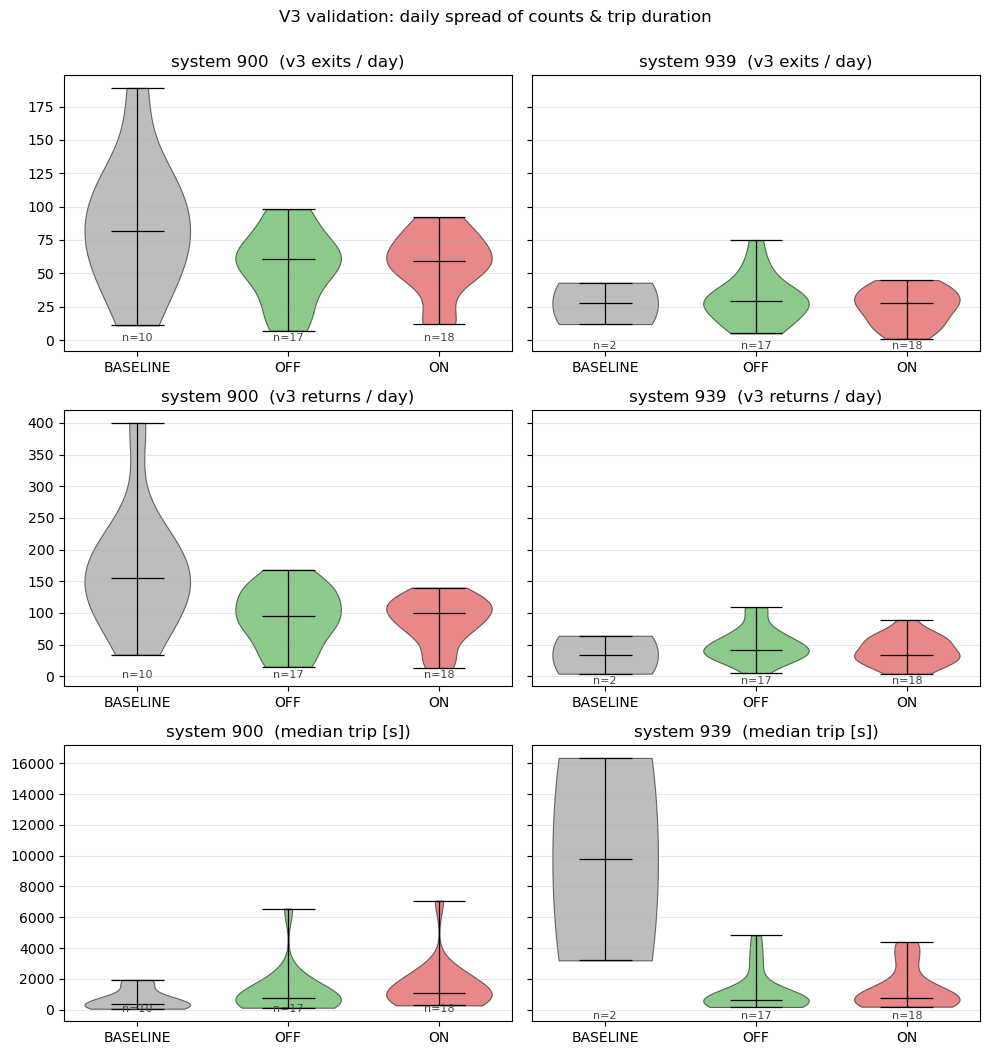

In [9]:

# V3 Validation 1 — Spread of exits / returns / trip duration per day
# ---------------------------------------------------------------------------
# Box plots of v3 counts and trip duration, per system, across all conditions.
# Y-axes are SHARED per metric (sharey="row") so the two systems are directly
# comparable. If the boxes are reasonably tight and BASELINE/OFF/ON span
# similar ranges with sensible variance, the classifier is consistent.

METRICS = [
    ("n_exit_v3",     "v3 exits / day",     False),
    ("n_return_v3",   "v3 returns / day",   False),
    ("median_trip_s", "median trip [s]",    False),
]

fig, axes = plt.subplots(len(METRICS), len(SYSTEMS),
                         figsize=(5 * len(SYSTEMS), 3.5 * len(METRICS)),
                         sharey="row", squeeze=False)

for r, (col, label, _) in enumerate(METRICS):
    for c, sys_id in enumerate(SYSTEMS):
        ax = axes[r, c]
        sub = daily[daily["system_id"] == sys_id]
        groups = [sub.loc[sub["condition"] == k, col].dropna().values
                  for k in CONDITION_ORDER]
        _violin_group(ax, groups, CONDITION_ORDER, CONDITION_COLORS, alpha=0.55)
        ax.set_title(f"system {sys_id}  ({label})")
        ax.grid(axis="y", alpha=0.3)
plt.suptitle("V3 validation: daily spread of counts & trip duration",
             fontsize=12, y=1.0)
plt.tight_layout()
plt.show()


## V3 validation 2 — v1 ↔ v3 per-day scatter

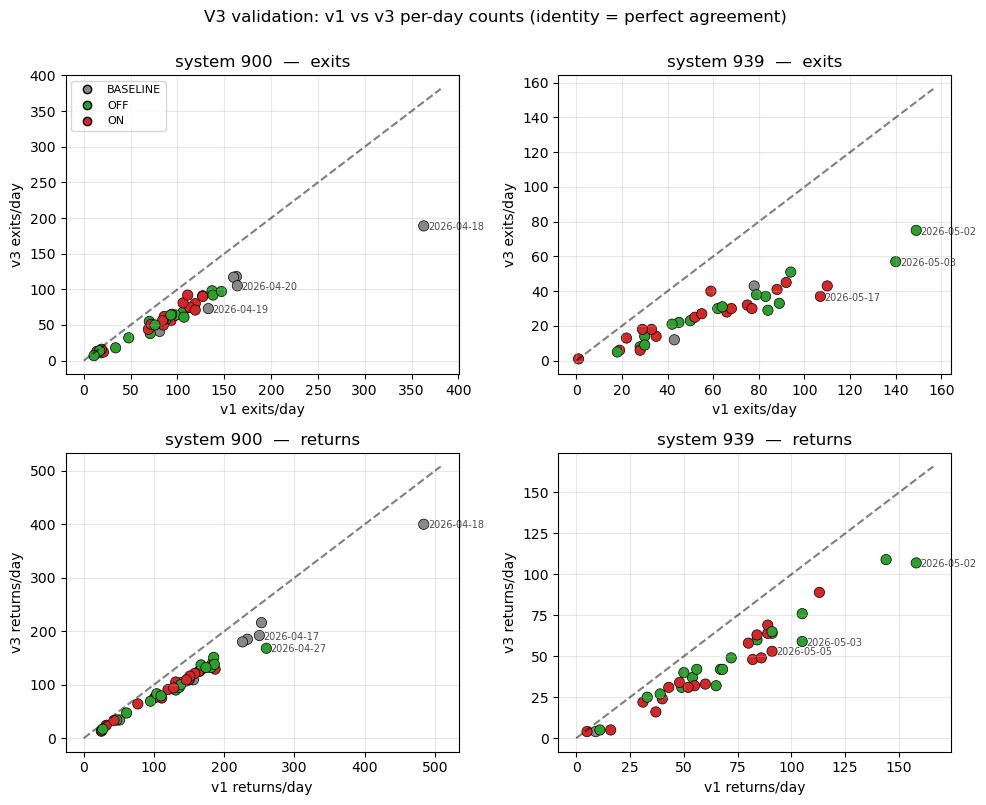


Per-system v1-v3 deltas:
  system 900: exits Δ +33.3±25.7  (min 1 max 174)  |  returns Δ +35.1±17.4  (min 8 max 92)
  system 939: exits Δ +34.3±19.3  (min 0 max 83)  |  returns Δ +21.9±11.2  (min 1 max 51)


In [10]:

# V3 Validation 2 — v1 ↔ v3 per-day scatter
# ---------------------------------------------------------------------------
# Each point is a day. v3 should fall slightly below or at v1 (v3 is strictly
# more selective). Days that drift far below the identity line are where v3
# is rejecting many tracks v1 accepted — visit them in the 3D viewer.

fig, axes = plt.subplots(2, len(SYSTEMS), figsize=(5 * len(SYSTEMS), 8),
                         squeeze=False)

for c, sys_id in enumerate(SYSTEMS):
    sub = daily[daily["system_id"] == sys_id]

    for r, (v1c, v3c, label) in enumerate([
        ("n_exit_v1",   "n_exit_v3",   "exits"),
        ("n_return_v1", "n_return_v3", "returns"),
    ]):
        ax = axes[r, c]
        if sub.empty:
            ax.set_title(f"system {sys_id}  ({label}): no data")
            continue
        colors = [CONDITION_COLORS[k] for k in sub["condition"]]
        ax.scatter(sub[v1c], sub[v3c], c=colors, s=55, edgecolor="black",
                   linewidth=0.5)
        lo = 0
        hi = max(sub[v1c].max(), sub[v3c].max()) * 1.05 or 1
        ax.plot([lo, hi], [lo, hi], "k--", alpha=0.5, label="identity")
        ax.set_xlabel(f"v1 {label}/day")
        ax.set_ylabel(f"v3 {label}/day")
        ax.set_title(f"system {sys_id}  —  {label}")
        ax.grid(alpha=0.3)
        # annotate biggest delta days
        delta = sub[v1c] - sub[v3c]
        top = delta.nlargest(3).index
        for idx in top:
            row = sub.loc[idx]
            ax.annotate(row["date"], (row[v1c], row[v3c]), fontsize=7,
                        alpha=0.7, xytext=(3, -3), textcoords="offset points")

# manual legend
handles = [plt.Line2D([0], [0], marker="o", linestyle="", color=v,
                       markeredgecolor="black", label=k)
           for k, v in CONDITION_COLORS.items()]
axes[0, 0].legend(handles=handles, loc="upper left", fontsize=8)
plt.suptitle("V3 validation: v1 vs v3 per-day counts (identity = perfect agreement)",
             fontsize=12, y=1.0)
plt.tight_layout()
plt.show()

# Per-day delta summary
print("\nPer-system v1-v3 deltas:")
for sys_id in SYSTEMS:
    sub = daily[daily["system_id"] == sys_id]
    if sub.empty:
        continue
    de = (sub["n_exit_v1"]   - sub["n_exit_v3"]).describe().round(1)
    dr = (sub["n_return_v1"] - sub["n_return_v3"]).describe().round(1)
    print(f"  system {sys_id}: exits Δ {de['mean']:+.1f}±{de['std']:.1f}  "
          f"(min {de['min']:.0f} max {de['max']:.0f})  |  "
          f"returns Δ {dr['mean']:+.1f}±{dr['std']:.1f}  "
          f"(min {dr['min']:.0f} max {dr['max']:.0f})")


## V3 validation 3 — Per-track feature distributions

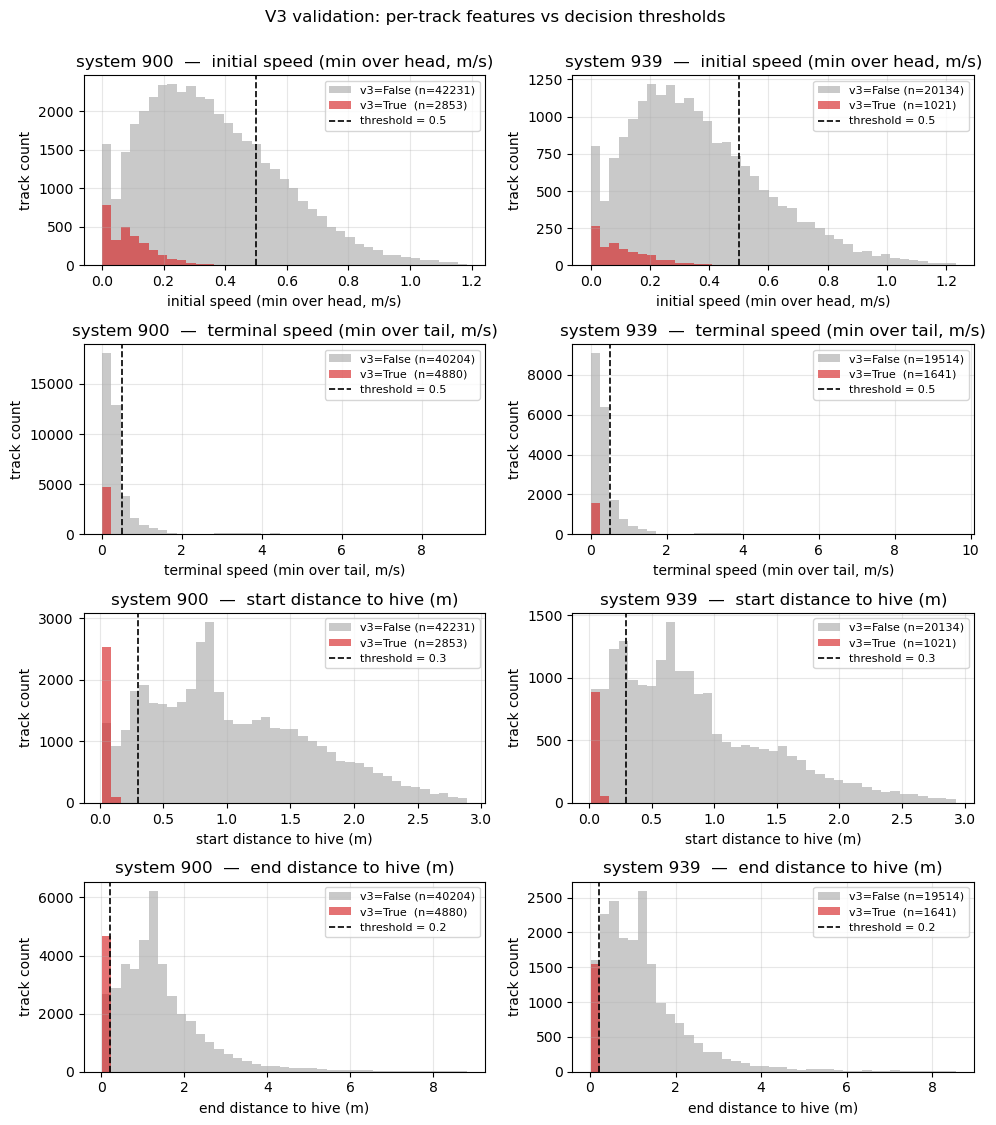

In [11]:

# V3 Validation 3 — Per-track feature distributions vs thresholds
# ---------------------------------------------------------------------------
# For each of the 4 main v3 features, plot the histogram of values across all
# tracks, split by whether the track was finally classified as a v3 exit (for
# initial_speed_min, start_dist) or v3 return (terminal_speed_min, end_dist).
# Threshold lines show where the cut is. If the threshold sits in a valley
# between two modes, it's well-placed; if it cuts through a peak, you'd
# expect over-rejection on one side or the other.

# Mirror the constants from the multi_day_v3 CONFIG
SPEED_THRESHOLD_TAKEOFF = 0.5
SPEED_THRESHOLD_LANDING = 0.5
START_NEAR_HIVE_MAX     = 0.30
END_NEAR_HIVE_MAX       = 0.20

PANELS = [
    ("initial_speed_min",  "hive_exit_v3",   SPEED_THRESHOLD_TAKEOFF,
     "initial speed (min over head, m/s)",         True),
    ("terminal_speed_min", "hive_return_v3", SPEED_THRESHOLD_LANDING,
     "terminal speed (min over tail, m/s)",        True),
    ("start_dist",         "hive_exit_v3",   START_NEAR_HIVE_MAX,
     "start distance to hive (m)",                 False),
    ("end_dist",           "hive_return_v3", END_NEAR_HIVE_MAX,
     "end distance to hive (m)",                   False),
]

fig, axes = plt.subplots(len(PANELS), len(SYSTEMS),
                         figsize=(5 * len(SYSTEMS), 2.8 * len(PANELS)),
                         squeeze=False)

for r, (feat, label_col, thr, xlabel, _) in enumerate(PANELS):
    for c, sys_id in enumerate(SYSTEMS):
        ax = axes[r, c]
        sub = tracks[tracks["system_id"] == sys_id]
        if sub.empty or feat not in sub.columns:
            ax.set_title(f"system {sys_id}: no data")
            continue
        true_vals  = sub.loc[sub[label_col] == True,  feat].dropna()
        false_vals = sub.loc[sub[label_col] == False, feat].dropna()
        # Determine a common range so the histograms are directly comparable
        all_vals = pd.concat([true_vals, false_vals])
        if all_vals.empty:
            continue
        lo, hi = float(all_vals.quantile(0.005)), float(all_vals.quantile(0.995))
        bins = np.linspace(lo, hi, 40)
        ax.hist(false_vals, bins=bins, alpha=0.45, color="#888",
                label=f"v3=False (n={len(false_vals)})")
        ax.hist(true_vals,  bins=bins, alpha=0.65, color="tab:red",
                label=f"v3=True  (n={len(true_vals)})")
        ax.axvline(thr, color="black", linestyle="--", linewidth=1.2,
                   label=f"threshold = {thr}")
        ax.set_title(f"system {sys_id}  —  {xlabel}")
        ax.legend(fontsize=8)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("track count")
        ax.grid(alpha=0.3)

plt.suptitle("V3 validation: per-track features vs decision thresholds",
             fontsize=12, y=1.0)
plt.tight_layout()
plt.show()


# Section A — Temporal context

merged flower-visit counts into daily (3193 total visits)


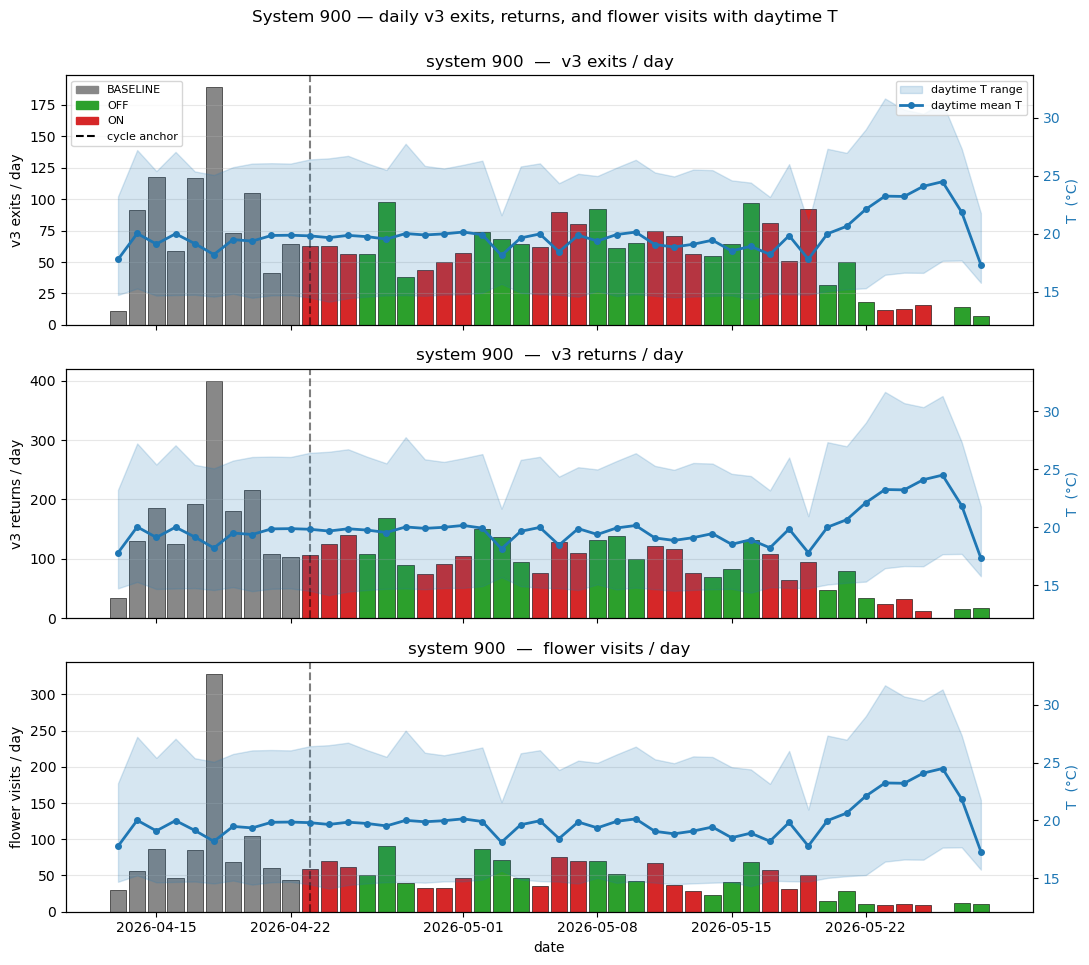

In [12]:

# Section A — Temporal context: per-system, exits / returns / flower visits
# ---------------------------------------------------------------------------
# One figure per system. Each figure has 3 rows: v3 exits, v3 returns, and
# flower-visit count. Bars coloured by condition; daytime temperature mean is
# overlaid on a secondary y-axis with the min/max range shown as a shaded band.

# ---- Merge flower-visit daily counts into `daily` so the third panel can use them ----
_FV_PATH = Path("data/multi_day") / "flower_visit_summary.csv"
if _FV_PATH.exists():
    _fv_daily = pd.read_csv(_FV_PATH)
    _fv_daily["date"] = pd.to_datetime(_fv_daily["date"]).dt.strftime("%Y-%m-%d")
    # rename to a clean column name and keep only what we need
    if "n_visits" not in _fv_daily.columns and "n_flower_visits" in _fv_daily.columns:
        _fv_daily = _fv_daily.rename(columns={"n_flower_visits": "n_visits"})
    _fv_daily = _fv_daily[["date", "system_id", "n_visits"]]
    # avoid duplicate-column collision on re-runs
    if "n_visits" in daily.columns:
        daily = daily.drop(columns=["n_visits"])
    daily = daily.merge(_fv_daily, on=["date", "system_id"], how="left")
    daily["n_visits"] = daily["n_visits"].fillna(0).astype(int)
    print(f"merged flower-visit counts into daily ({daily['n_visits'].sum()} total visits)")
else:
    daily["n_visits"] = 0
    print(f"!! {_FV_PATH} not found — flower-visit panel will be empty")

METRICS_A = [
    ("n_exit_v3",   "v3 exits / day"),
    ("n_return_v3", "v3 returns / day"),
    ("n_visits",    "flower visits / day"),
]


def plot_daily_per_system(sys_id):
    fig, axes = plt.subplots(len(METRICS_A), 1, figsize=(11, 3.2 * len(METRICS_A)),
                             sharex=True, squeeze=False)
    for r, (metric_col, metric_label) in enumerate(METRICS_A):
        ax = axes[r, 0]
        sub = daily[daily["system_id"] == sys_id].sort_values("date").copy()
        sub["date_ts"] = pd.to_datetime(sub["date"])
        colors = [CONDITION_COLORS[k] for k in sub["condition"]]

        # Bars: daily count
        ax.bar(sub["date_ts"], sub[metric_col], color=colors,
               edgecolor="black", linewidth=0.4, width=0.85)
        ax.axvline(CYCLE_ANCHOR, linestyle="--", color="black", alpha=0.5)
        ax.set_title(f"system {sys_id}  —  {metric_label}")
        ax.set_ylabel(metric_label)
        ax.grid(axis="y", alpha=0.3)

        # Temperature on secondary axis (mean line + min/max shaded band)
        if temp_daily is not None and not temp_daily.empty:
            ax2 = ax.twinx()
            tw = temp_daily[
                (temp_daily["date_ts"] >= sub["date_ts"].min())
                & (temp_daily["date_ts"] <= sub["date_ts"].max())
            ].sort_values("date_ts")
            if not tw.empty:
                ax2.fill_between(tw["date_ts"], tw["temp_min"], tw["temp_max"],
                                 color="tab:blue", alpha=0.18,
                                 label="daytime T range")
                ax2.plot(tw["date_ts"], tw["temp_mean"], color="tab:blue",
                         linewidth=2.0, marker="o", markersize=4,
                         label="daytime mean T")
                ax2.set_ylabel("T  (°C)", color="tab:blue")
                ax2.tick_params(axis="y", labelcolor="tab:blue")
                # share a sensible T-axis across both rows
                ax2.set_ylim(max(0, tw["temp_min"].min() - 2),
                              tw["temp_max"].max() + 2)
                if r == 0:
                    ax2.legend(loc="upper right", fontsize=8)

        if r == 0:
            handles = [plt.Rectangle((0, 0), 1, 1, color=v, label=k)
                       for k, v in CONDITION_COLORS.items()]
            handles.append(plt.Line2D([0], [0], color="black", linestyle="--",
                                       label="cycle anchor"))
            ax.legend(handles=handles, fontsize=8, loc="upper left")

    axes[-1, 0].set_xlabel("date")
    plt.suptitle(f"System {sys_id} — daily v3 exits, returns, and flower visits with daytime T",
                 fontsize=12, y=1.0)
    plt.tight_layout()
    plt.show()


#for sys_id in SYSTEMS:
    #plot_daily_per_system(sys_id)

# Call the function directly for just system 900
plot_daily_per_system(900)



sys 900 - hour-by-hour ON-vs-OFF:
  hour   ON med   OFF med   p (raw)    p (BH)
     9      0.0       0.0     0.946     0.987
    10     17.0      14.0     0.088     0.616
    11      9.5      10.0     0.895     0.987
    12      9.5       8.0     0.987     0.987
    13      6.0      11.0     0.246     0.730
    14      3.0       7.0     0.313     0.730
    15      1.0       1.0     0.721     0.987

sys 939 - hour-by-hour ON-vs-OFF:
  hour   ON med   OFF med   p (raw)    p (BH)
     9      0.0       0.0     0.900     0.947
    10      4.5       4.0     0.607     0.947
    11      5.0       5.0     0.947     0.947
    12      3.0       7.0     0.119     0.439
    13      3.0       4.0     0.485     0.947
    14      2.5       3.0     0.751     0.947
    15      0.0       1.0     0.125     0.439


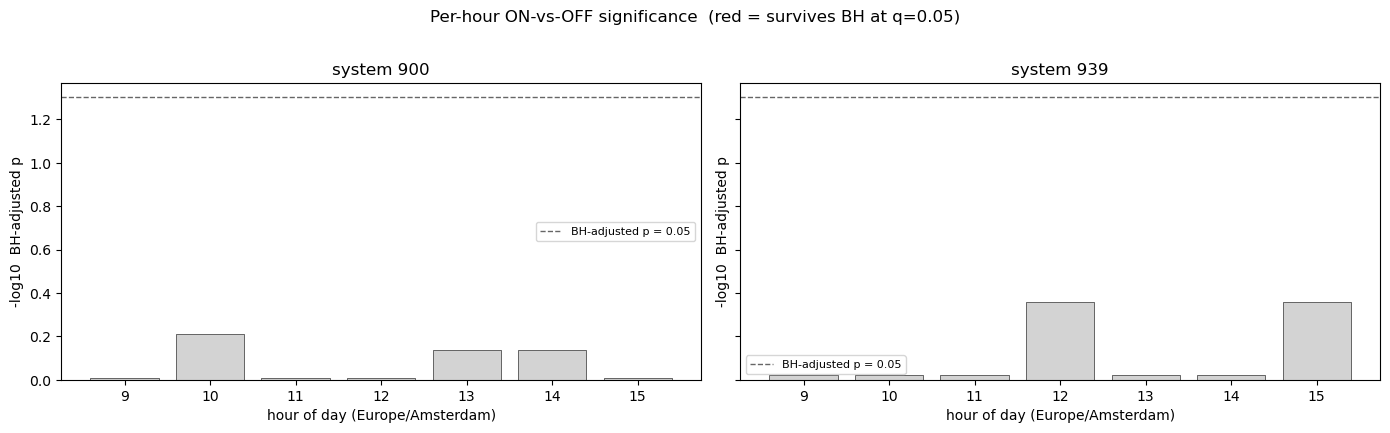

In [16]:
from scipy import stats
from scipy.stats import false_discovery_control

# Build the (date, system, hour) -> count table
tracks_with_hour = tracks[tracks["hive_exit_v3"] == True].copy()
tracks_with_hour["hour"] = tracks_with_hour["ts"].dt.hour
tracks_with_hour["date"] = tracks_with_hour["ts"].dt.date

hourly = (tracks_with_hour
          .groupby(["date", "system_id", "hour"]).size()
          .rename("n_v3").reset_index())
hourly["date"]      = pd.to_datetime(hourly["date"])
hourly["condition"] = hourly["date"].apply(condition_for)

ACTIVE_HOURS = list(range(9, 16))  # 09:00 .. 15:59 (active foraging window)

fig, axes = plt.subplots(1, len(systems), figsize=(7 * len(systems), 4.2),
                         sharey=True, squeeze=False)

for ax, sid in zip(axes[0], systems):
    pvals, on_med, off_med = [], [], []
    for h in ACTIVE_HOURS:
        sub = hourly[(hourly["system_id"] == sid) & (hourly["hour"] == h)]
        # Fill in missing (date, system, hour) zeros: a date with no exits at hour h
        # should count as 0, not be silently dropped.
        all_dates = daily.loc[daily["system_id"] == sid, "date"]
        all_dates = pd.to_datetime(all_dates)
        full = pd.DataFrame({"date": all_dates})
        full["condition"] = full["date"].apply(condition_for)
        full = full.merge(sub[["date", "n_v3"]], on="date", how="left").fillna(0)

        on  = full.loc[full["condition"] == "ON",  "n_v3"]
        off = full.loc[full["condition"] == "OFF", "n_v3"]
        if len(on) and len(off):
            try:
                p = stats.mannwhitneyu(on, off, alternative="two-sided").pvalue
            except ValueError:
                p = 1.0
        else:
            p = 1.0
        pvals.append(p)
        on_med.append(on.median()); off_med.append(off.median())

    pvals = np.asarray(pvals)
    p_adj = false_discovery_control(pvals, method="bh")

    # bar of -log10 p_adj
    bars = ax.bar(ACTIVE_HOURS, -np.log10(np.clip(p_adj, 1e-3, 1)),
                  color=["tab:red" if p < 0.05 else "lightgrey" for p in p_adj],
                  edgecolor="black", linewidth=0.4)
    ax.axhline(-np.log10(0.05), color="black", ls="--", lw=1, alpha=0.6,
               label="BH-adjusted p = 0.05")
    ax.set_xticks(ACTIVE_HOURS)
    ax.set_xlabel("hour of day (Europe/Amsterdam)")
    ax.set_ylabel("-log10  BH-adjusted p")
    ax.set_title(f"system {sid}")
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=8)

    # Annotate: print the table for this system
    print(f"\nsys {sid} - hour-by-hour ON-vs-OFF:")
    print(f"  {'hour':>4s} {'ON med':>8s} {'OFF med':>9s} {'p (raw)':>9s} {'p (BH)':>9s}")
    for h, om, fm, p, pa in zip(ACTIVE_HOURS, on_med, off_med, pvals, p_adj):
        flag = "  *" if pa < 0.05 else ""
        print(f"  {h:>4d} {om:>8.1f} {fm:>9.1f} {p:>9.3f} {pa:>9.3f}{flag}")

fig.suptitle("Per-hour ON-vs-OFF significance  (red = survives BH at q=0.05)",
             y=1.02)
plt.tight_layout()
plt.show()


# Section B.2 - Behavioural anchors

Three per-(date, system) summaries that adapt to weather-driven shifts in the daily curve, instead of pinning a clock-time:

- **`first_exit_hour`** - hour of the first v3 exit. Sensitive to "activation" effects.
- **`peak_hour`** - hour with the most v3 exits. Sensitive to *when* foraging is concentrated.
- **`active_hours`** - count of hours with > 5 v3 exits. Sensitive to the *length* of the active window.

If a cold morning shifts the whole curve later, the *peak hour* shifts with it — so comparing peak hours between conditions is comparing like-for-like behaviour rather than like-for-like clock-time.


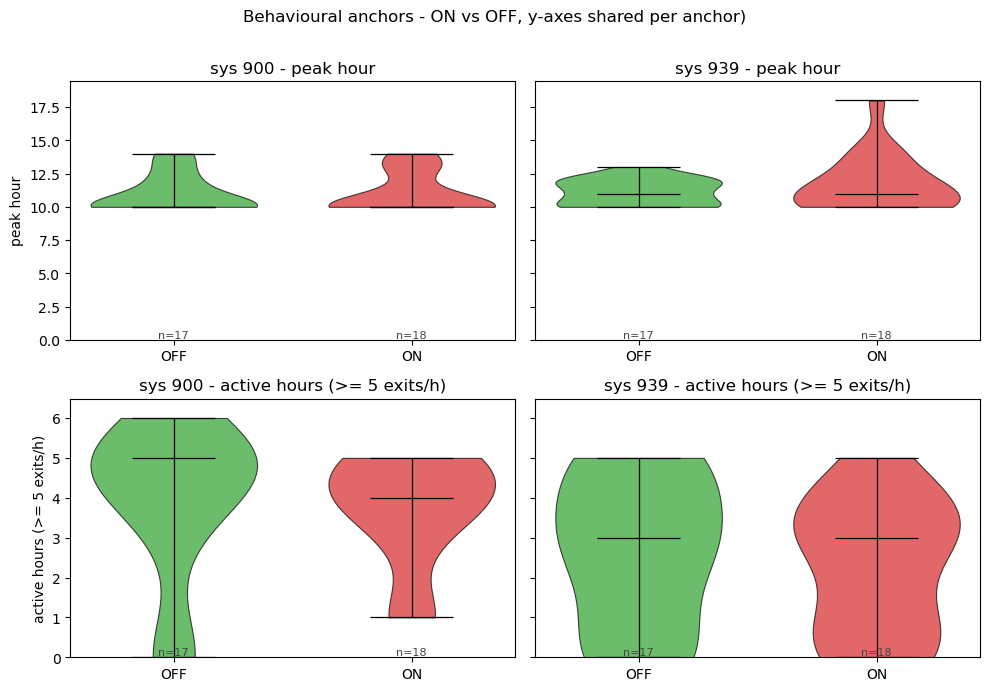


anchor                     sys   ON med   OFF med   p (MWU)
  peak hour                900     10.0      10.0     1.000
  peak hour                939     11.0      11.0     0.692
  active hours (>= 5 exits/h)  900      4.0       5.0     0.312
  active hours (>= 5 exits/h)  939      3.0       3.0     0.567


In [31]:
ACTIVITY_THRESHOLD = 5  # exits/hour to count as "active"
C_ORDER  = ["OFF", "ON"]

# Build per-(date, system) anchors
anchors_rows = []
for (d, sid), grp in tracks_with_hour.groupby(["date", "system_id"]):
    counts = grp.groupby("hour").size()
    if counts.empty:
        continue
    anchors_rows.append({
        "date":             pd.Timestamp(d),
        "system_id":        sid,
        "peak_hour":        int(counts.idxmax()),
        "peak_count":       int(counts.max()),
        "active_hours":     int((counts >= ACTIVITY_THRESHOLD).sum()),
    })
anchors = pd.DataFrame(anchors_rows)
anchors["condition"] = anchors["date"].apply(condition_for)

ANCHORS = [("peak_hour",       "peak hour"),
           ("active_hours",    f"active hours (>= {ACTIVITY_THRESHOLD} exits/h)")]

contrast_anchors = anchors[anchors["condition"].isin(["OFF", "ON"])]
if contrast_anchors.empty:
    print("No ON/OFF anchor data yet.")
else:
    fig, axes = plt.subplots(len(ANCHORS), len(systems),
                             figsize=(5 * len(systems), 3.4 * len(ANCHORS)),
                             sharey="row",  # same y-axis across systems per anchor
                             squeeze=False)
    for r, (col, label) in enumerate(ANCHORS):
        # global max so the shared y starts at 0 and reaches the larger system
        ymax = contrast_anchors[col].max()
        for c_ax, sid in enumerate(systems):
            ax = axes[r, c_ax]
            sub = contrast_anchors[contrast_anchors["system_id"] == sid]
            # Build the per-condition groups (one array per OFF / ON).
            groups = [sub.loc[sub["condition"] == k, col].dropna().values
                      for k in C_ORDER]
            # Set ylim BEFORE the violin helper so the n=... labels (which read
            # ax.get_ylim()[0]) land at the visible axis bottom rather than at
            # an auto-scaled value that get_ylim() returns mid-plot.
            ax.set_ylim(0, ymax * 1.08 if ymax > 0 else 1)
            _violin_group(ax, groups, C_ORDER, COLORS, alpha=0.7)
            ax.set_title(f"sys {sid} - {label}")
            if c_ax == 0:
                ax.set_ylabel(label)
    fig.suptitle("Behavioural anchors - ON vs OFF, y-axes shared per anchor)",
                 y=1.01)
    plt.tight_layout()
    plt.show()

    # Stat tests
    print(f"\n{'anchor':25s} {'sys':>4s} {'ON med':>8s} {'OFF med':>9s} {'p (MWU)':>9s}")
    for col, label in ANCHORS:
        for sid in systems:
            sub = contrast_anchors[contrast_anchors["system_id"] == sid]
            on  = sub.loc[sub["condition"] == "ON",  col].dropna()
            off = sub.loc[sub["condition"] == "OFF", col].dropna()
            if len(on) and len(off):
                p = stats.mannwhitneyu(on, off, alternative="two-sided").pvalue
                print(f"  {label:23s} {sid:>4d} {on.median():>8.1f} {off.median():>9.1f} {p:>9.3f}")


# Section B — BASELINE BASELINE reference

In [32]:

# Section B — BASELINE BASELINE reference
# ---------------------------------------------------------------------------

BASELINE_cols = ["n_exit_v3", "n_return_v3", "re_ratio_v3",
                 "median_trip_s", "mean_trip_s", "n_matched"]

BASELINE = daily[daily["condition"] == "BASELINE"]
print(f"BASELINE days: {len(BASELINE)}")
if not BASELINE.empty:
    summary = (BASELINE.groupby("system_id")[BASELINE_cols]
               .agg(["mean", "std", "median", "min", "max", "count"]))
    print()
    print(summary.round(2).to_string())
else:
    print("(no BASELINE days in this date range)")


BASELINE days: 12

          n_exit_v3                              n_return_v3                              re_ratio_v3                                median_trip_s                                         mean_trip_s                                            n_matched                             
               mean    std median min  max count        mean    std median min  max count        mean   std median   min   max count          mean      std  median     min      max count        mean      std   median      min       max count      mean    std median min  max count
system_id                                                                                                                                                                                                                                                                               
900            86.8  49.45   82.0  11  189    10       167.5  97.73  155.0  34  400    10        2.08  0.54   2.09  1.43  3.09    10      

# Section C — ON vs OFF

## C.4 Daily metrics boxplots

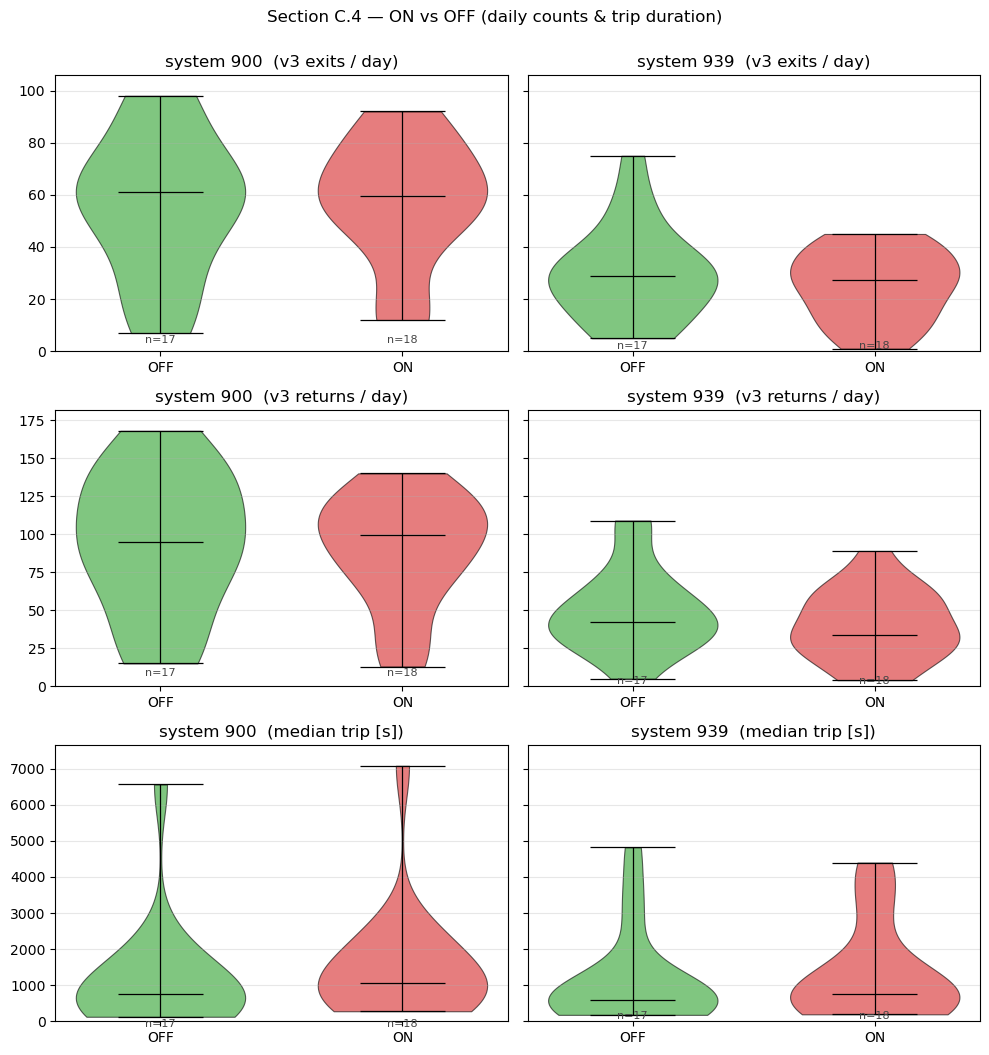

In [33]:

# Section C.4 — ON vs OFF box plots (aligned y-axes per metric)
# ---------------------------------------------------------------------------

C_METRICS = [
    ("n_exit_v3",     "v3 exits / day",   0),
    ("n_return_v3",   "v3 returns / day", 0),
    ("median_trip_s", "median trip [s]",  0),
]
C_ORDER  = ["OFF", "ON"]
C_COLORS = {"OFF": "tab:green", "ON": "tab:red"}

fig, axes = plt.subplots(len(C_METRICS), len(SYSTEMS),
                         figsize=(5 * len(SYSTEMS), 3.5 * len(C_METRICS)),
                         sharey="row", squeeze=False)

for r, (col, label, lo) in enumerate(C_METRICS):
    # First pass: compute shared row ylim from the data
    row_max = 0
    for sys_id in SYSTEMS:
        sub = daily[(daily["system_id"] == sys_id)
                    & (daily["condition"].isin(C_ORDER))]
        if not sub.empty:
            row_max = max(row_max, sub[col].max(skipna=True) or 0)
    for c, sys_id in enumerate(SYSTEMS):
        ax = axes[r, c]
        sub = daily[(daily["system_id"] == sys_id)
                    & (daily["condition"].isin(C_ORDER))]
        groups = [sub.loc[sub["condition"] == k, col].dropna().values
                  for k in C_ORDER]
        _violin_group(ax, groups, C_ORDER, C_COLORS, alpha=0.6)
        ax.set_title(f"system {sys_id}  ({label})")
        ax.set_ylim(lo, row_max * 1.08 if row_max > 0 else 1)
        ax.grid(axis="y", alpha=0.3)
plt.suptitle("Section C.4 — ON vs OFF (daily counts & trip duration)",
             fontsize=12, y=1.0)
plt.tight_layout()
plt.show()


## C.5 Per-track tortuosity

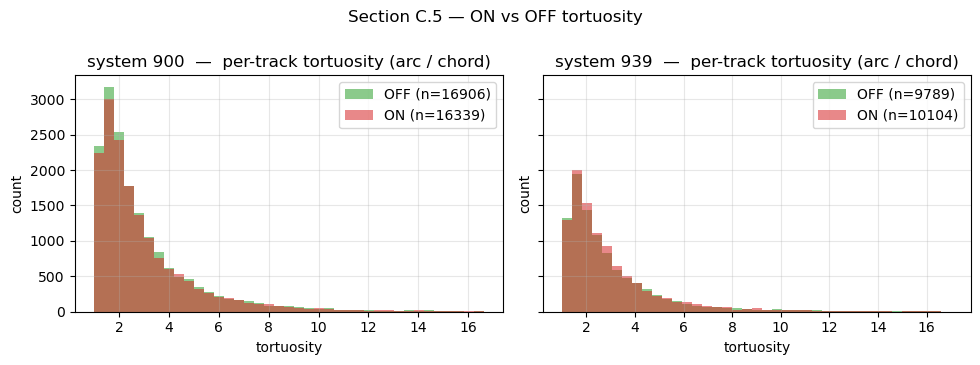

In [20]:

# Section C.5 — ON vs OFF tortuosity (per-track distribution)
# ---------------------------------------------------------------------------

if "tortuosity" in tracks.columns:
    fig, axes = plt.subplots(1, len(SYSTEMS), figsize=(5 * len(SYSTEMS), 3.6),
                             sharey=True, squeeze=False)
    for c, sys_id in enumerate(SYSTEMS):
        ax = axes[0, c]
        sub = tracks[(tracks["system_id"] == sys_id)
                     & tracks["condition"].isin(["OFF", "ON"])]
        if sub.empty:
            continue
        bins = np.linspace(1, np.nanpercentile(sub["tortuosity"], 99.5), 40)
        for k in ["OFF", "ON"]:
            vals = sub.loc[sub["condition"] == k, "tortuosity"].dropna()
            ax.hist(vals, bins=bins, alpha=0.55, label=f"{k} (n={len(vals)})",
                    color=C_COLORS[k])
        ax.set_title(f"system {sys_id}  —  per-track tortuosity (arc / chord)")
        ax.set_xlabel("tortuosity")
        ax.set_ylabel("count")
        ax.legend()
        ax.grid(alpha=0.3)
    plt.suptitle("Section C.5 — ON vs OFF tortuosity",
                 fontsize=12, y=1.0)
    plt.tight_layout()
    plt.show()
else:
    print("tortuosity column missing from per_track — re-run multi_day_v3")


## C.7 Mann-Whitney U (ON vs OFF)

In [21]:

# Section C.7 — Mann-Whitney U (ON vs OFF), daily metrics + tortuosity
# ---------------------------------------------------------------------------

def _mwu(on_vals, off_vals):
    on_v  = pd.Series(on_vals).dropna()
    off_v = pd.Series(off_vals).dropna()
    if len(on_v) < 2 or len(off_v) < 2:
        return np.nan, np.nan, len(on_v), len(off_v)
    u, p = stats.mannwhitneyu(on_v, off_v, alternative="two-sided")
    return float(u), float(p), len(on_v), len(off_v)


rows = []
for sys_id in SYSTEMS:
    sub_day = daily[(daily["system_id"] == sys_id)
                    & daily["condition"].isin(["OFF", "ON"])]
    for col, label, _ in C_METRICS:
        on  = sub_day.loc[sub_day["condition"] == "ON",  col]
        off = sub_day.loc[sub_day["condition"] == "OFF", col]
        u, p, n_on, n_off = _mwu(on, off)
        rows.append({
            "system_id": sys_id, "metric": label, "source": "daily",
            "n_on": n_on, "n_off": n_off, "U": u, "p": p,
            "mean_on":  float(on.mean())  if len(on)  else np.nan,
            "mean_off": float(off.mean()) if len(off) else np.nan,
        })
    if "tortuosity" in tracks.columns:
        sub_trk = tracks[(tracks["system_id"] == sys_id)
                         & tracks["condition"].isin(["OFF", "ON"])]
        on  = sub_trk.loc[sub_trk["condition"] == "ON",  "tortuosity"]
        off = sub_trk.loc[sub_trk["condition"] == "OFF", "tortuosity"]
        u, p, n_on, n_off = _mwu(on, off)
        rows.append({
            "system_id": sys_id, "metric": "tortuosity (per track)",
            "source": "tracks", "n_on": n_on, "n_off": n_off,
            "U": u, "p": p,
            "mean_on":  float(on.mean())  if len(on)  else np.nan,
            "mean_off": float(off.mean()) if len(off) else np.nan,
        })

mwu_table = pd.DataFrame(rows)
print(mwu_table.round(4).to_string(index=False))


 system_id                 metric source  n_on  n_off           U      p   mean_on  mean_off
       900         v3 exits / day  daily    18     17       154.0 0.9868   57.3333   56.0588
       900       v3 returns / day  daily    18     17       139.5 0.6678   89.3889   93.8824
       900        median trip [s]  daily    18     17       201.0 0.1169 1505.5000 1142.3235
       900 tortuosity (per track) tracks 16339  16906 138976382.0 0.3240    3.1379    3.1036
       939         v3 exits / day  daily    18     17       136.0 0.5858   25.2222   30.1176
       939       v3 returns / day  daily    18     17       122.5 0.3217   40.2778   49.8824
       939        median trip [s]  daily    18     17       174.0 0.4987 1364.2222 1127.4412
       939 tortuosity (per track) tracks 10104   9789  49562958.0 0.7879    3.0651    3.0931


# Section K — Indicator dashboard

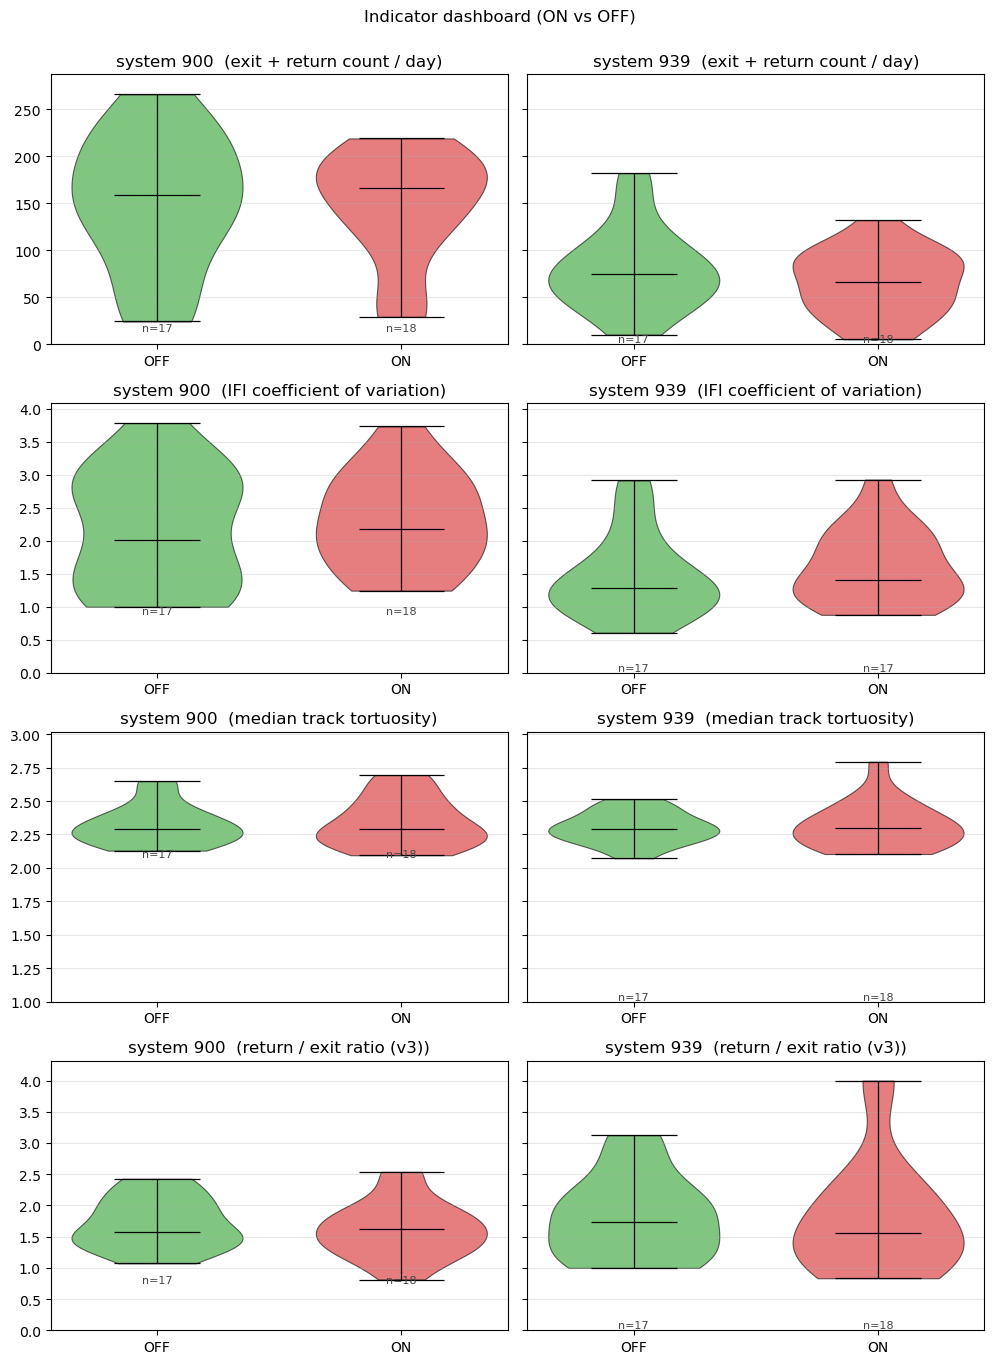

 system_id                    indicator  n_on  n_off     U      p  p_BH       r  mean_on  mean_off  directional
       900    exit + return count / day    18     17 144.5 0.7917 0.908  0.0556 146.7222  149.9412        False
       900 IFI coefficient of variation    18     17 168.0 0.6322 0.908 -0.0980   2.3046    2.1731        False
       900      median track tortuosity    18     17 157.0 0.9080 0.908 -0.0261   2.3421    2.3212        False
       900     return / exit ratio (v3)    18     17 132.0 0.4986 0.908  0.1373   1.6210    1.7150        False
       939    exit + return count / day    18     17 130.5 0.4677 0.908  0.1471  65.5000   80.0000        False
       939 IFI coefficient of variation    17     17 172.0 0.3524 0.908 -0.1903   1.6098    1.4580        False
       939      median track tortuosity    18     17 157.0 0.9080 0.908 -0.0261   2.3201    2.3010        False
       939     return / exit ratio (v3)    18     17 144.0 0.7790 0.908  0.0588   1.8226    1.8147      

In [22]:

# Section K — Indicator dashboard (4 indicators × 2 systems)
# ---------------------------------------------------------------------------
# Per-day indicators with BH-corrected Mann-Whitney + rank-biserial effect size.
# Vertical-behaviour (5th in legacy) needs median-z per track, which the v3
# pipeline doesn\'t currently persist — port from legacy if needed.

def _per_day_ifi_cv(group):
    ts = group.loc[group["hive_exit_v3"], "ts"].sort_values()
    if len(ts) < 3:
        return np.nan
    iv = pd.to_datetime(ts).diff().dropna().dt.total_seconds()
    if iv.mean() == 0:
        return np.nan
    return float(iv.std() / iv.mean())


def _per_day_tortuosity(group):
    return float(group["tortuosity"].median())


# Build the per-(date, system) indicator frame from `tracks`
ifi  = (tracks.groupby(["date", "system_id"])
              .apply(_per_day_ifi_cv, include_groups=False)
              .reset_index(name="ifi_cv"))
if "tortuosity" in tracks.columns:
    tort = (tracks.groupby(["date", "system_id"])
                  .apply(_per_day_tortuosity, include_groups=False)
                  .reset_index(name="path_tortuosity"))
else:
    tort = pd.DataFrame(columns=["date", "system_id", "path_tortuosity"])

contrast = (daily.merge(ifi,  on=["date", "system_id"], how="left")
                  .merge(tort, on=["date", "system_id"], how="left"))
contrast["re_ratio"] = contrast["re_ratio_v3"]

INDICATORS = [
    ("exit_return_count", "exit + return count / day", 0),
    ("ifi_cv",            "IFI coefficient of variation", 0),
    ("path_tortuosity",   "median track tortuosity", 1),
    ("re_ratio",          "return / exit ratio (v3)", 0),
]

ORDER  = ["OFF", "ON"]
COLORS = {"OFF": "tab:green", "ON": "tab:red"}


def rank_biserial(on_vals, off_vals):
    on_v, off_v = np.asarray(on_vals), np.asarray(off_vals)
    n1, n2 = len(on_v), len(off_v)
    if n1 == 0 or n2 == 0:
        return np.nan
    u, _ = stats.mannwhitneyu(on_v, off_v, alternative="two-sided")
    return 1.0 - (2.0 * u) / (n1 * n2)


# 1) Violin plot
fig, axes = plt.subplots(len(INDICATORS), len(SYSTEMS),
                         figsize=(5 * len(SYSTEMS), 3.4 * len(INDICATORS)),
                         sharey="row", squeeze=False)
for r, (col, label, lo) in enumerate(INDICATORS):
    row_max = 0
    for sys_id in SYSTEMS:
        sub = contrast[(contrast["system_id"] == sys_id)
                       & contrast["condition"].isin(ORDER)]
        if not sub.empty:
            row_max = max(row_max, sub[col].max(skipna=True) or 0)
    for c, sys_id in enumerate(SYSTEMS):
        ax = axes[r, c]
        sub = contrast[(contrast["system_id"] == sys_id)
                       & contrast["condition"].isin(ORDER)]
        groups = [sub.loc[sub["condition"] == k, col].dropna().values
                  for k in ORDER]
        _violin_group(ax, groups, ORDER, COLORS, alpha=0.6)
        ax.set_title(f"system {sys_id}  ({label})")
        ax.set_ylim(lo, row_max * 1.08 if row_max > 0 else 1)
        ax.grid(axis="y", alpha=0.3)
plt.suptitle("Indicator dashboard (ON vs OFF)", fontsize=12, y=1.0)
plt.tight_layout()
plt.show()


# 2) Stat tests with BH correction
from scipy.stats import false_discovery_control

rows = []
for sys_id in SYSTEMS:
    sub = contrast[(contrast["system_id"] == sys_id)
                   & contrast["condition"].isin(ORDER)]
    pvals = []
    record = []
    for col, label, _ in INDICATORS:
        on  = sub.loc[sub["condition"] == "ON",  col].dropna()
        off = sub.loc[sub["condition"] == "OFF", col].dropna()
        if len(on) < 2 or len(off) < 2:
            pvals.append(np.nan)
            record.append((sys_id, label, len(on), len(off), np.nan, np.nan,
                            np.nan, np.nan, np.nan))
            continue
        u, p = stats.mannwhitneyu(on, off, alternative="two-sided")
        r = rank_biserial(on, off)
        pvals.append(p)
        record.append((sys_id, label, len(on), len(off), float(u),
                        float(p), float(r), float(on.mean()), float(off.mean())))
    # BH correction across this system\'s indicators
    valid_p = [p for p in pvals if not (p is None or np.isnan(p))]
    if valid_p:
        adj = false_discovery_control(valid_p)
        adj_iter = iter(adj)
        adj_all = [float(next(adj_iter)) if not (p is None or np.isnan(p)) else np.nan
                   for p in pvals]
    else:
        adj_all = [np.nan] * len(pvals)
    for rec, p_adj in zip(record, adj_all):
        sys_id_, label, n_on, n_off, u, p, r, m_on, m_off = rec
        rows.append({"system_id": sys_id_, "indicator": label,
                      "n_on": n_on, "n_off": n_off,
                      "U": u, "p": p, "p_BH": p_adj, "r": r,
                      "mean_on": m_on, "mean_off": m_off,
                      "directional": (abs(r) > 0.3) if (r is not None and not np.isnan(r)) else False})

dash = pd.DataFrame(rows)
print(dash.round(4).to_string(index=False))


In [23]:
from scipy import stats
ind_df = pd.read_csv("data/multi_day/indicators_daily.csv")
ind_df["date_ts"]   = pd.to_datetime(ind_df["date"])
ind_df["condition"] = ind_df["date_ts"].apply(condition_for)
ind_df["exit_return_count"] = ind_df["n_v3"] + ind_df["n_returns"]

INDS = ["exit_return_count", "re_ratio_v3", "path_tortuosity",
        "ifi_cv", "mean_handling_time_s", "n_distinct_flowers"]

rows = []
for sid in sorted(ind_df["system_id"].unique()):
    for ind in INDS:
        if ind not in ind_df.columns: continue
        for cond in ["ON", "OFF"]:
            vals = ind_df[(ind_df.system_id == sid)
                          & (ind_df.condition == cond)][ind].dropna()
            if len(vals) < 3: continue
            sk = float(stats.skew(vals))
            ku = float(stats.kurtosis(vals))
            W, p = stats.shapiro(vals)
            rows.append({
                "system":  sid, "indicator": ind, "condition": cond,
                "n":       len(vals),
                "skew":    round(sk, 2), "kurtosis": round(ku, 2),
                "shapiro_W": round(W, 3), "shapiro_p": round(p, 4),
                "normal?": "yes" if p > 0.05 else "no",
            })

print(pd.DataFrame(rows).to_string(index=False))

KeyError: 'n_v3'

# Section L — Heading dispersion (directional confusion)

For every PATS-C track we compute two horizontal headings in the top-down
($xz$) plane: an **entry heading** (direction of the bee over the first five
frames of the track) and an **exit heading** (direction over the last five
frames). Headings are stored per track and cached in
`data/multi_day_v3/track_headings.csv` so that re-runs are instant.

The test is a permutation test on the **mean resultant length** $R$ of the
circular heading distribution, separately for entry and exit, per system:

- $R \in [0, 1]$. $R = 1$ means all bees flew in the same direction;
  $R = 0$ means the distribution is uniform on the circle.
- The null is "ON and OFF distributions are equal." Under the null, shuffling
  the ON/OFF labels and recomputing $\Delta R = R_{\mathrm{ON}} - R_{\mathrm{OFF}}$
  should reproduce the observed $|\Delta R|$ at most by chance.
- $5000$ shuffles. The $p$-value is the fraction of shuffles whose
  $|\Delta R|$ matched or exceeded the observed value.

A negative $\Delta R$ ($R_{\mathrm{ON}} < R_{\mathrm{OFF}}$) under exposure is the
direction predicted by the "directional confusion" hypothesis: bees are less
consistent in their bearings under RF exposure.


In [24]:
import numpy as np
from pathlib import Path

GEOM_CSV    = Path("data/multi_day/track_geometry.csv")
HEATMAP_CSV = Path("data/multi_day/heatmap_samples.csv")

# Constants matching multi_day_pipeline.ipynb / components.ipynb
TOL          = 0.10
HEAD_FRAMES  = 5
HIVE_BY_SYSTEM = {
    900: np.array([-0.04,  -0.665, -1.195]),
    939: np.array([-0.086, -0.828, -1.045]),
}
HEATMAP_DECIMATION = 10  # keep every Nth valid sample

# Read raw recordings from data/flight_data/ - the cache is bypassed because
# it has been out of date (missing 4/14-4/18 for sys 900).
DATA_BASE = Path("../../data/flight_data")
import re
folder_re = re.compile(r"^(\d{4}-\d{2}-\d{2})_system_(\d+)$")


def heading_deg(p_far, p_near):
    """Bearing in degrees from p_near to p_far in the XY plane.
    0° = +X, 90° = +Y. Returns NaN if motion is degenerate."""
    dx = p_far[0] - p_near[0]
    dy = p_far[1] - p_near[1]
    if abs(dx) < 1e-9 and abs(dy) < 1e-9:
        return np.nan
    return float(np.degrees(np.arctan2(dy, dx)))


def collect():
    """Walk data/flight_data/, compute per-track geometry and heatmap samples."""
    rows, samples = [], []
    folders = sorted(DATA_BASE.iterdir()) if DATA_BASE.exists() else []
    for f in folders:
        m = folder_re.match(f.name)
        if not m:
            continue
        date_str, sid_str = m.group(1), m.group(2)
        sid = int(sid_str)
        if sid not in HIVE_BY_SYSTEM:
            continue
        hive = HIVE_BY_SYSTEM[sid]

        ft_csv = f / "flight_tracks.csv"
        if not ft_csv.exists():
            continue

        try:
            ft = pd.read_csv(ft_csv,
                             usecols=["detection_uid", "pos_valid_insect",
                                      "posX_insect", "posY_insect", "posZ_insect",
                                      "elapsed"])
        except Exception as e:
            print(f"  skip {f.name}: {e}")
            continue

        ft = ft[ft["pos_valid_insect"] == 1]
        if len(ft) == 0:
            continue

        for uid, grp in ft.groupby("detection_uid"):
            grp = grp.sort_values("elapsed")
            if len(grp) < HEAD_FRAMES + 1:
                continue
            xyz = grp[["posX_insect", "posY_insect", "posZ_insect"]].to_numpy(float)
            p0, pn = xyz[0], xyz[-1]
            d0 = float(np.linalg.norm(p0 - hive))
            dn = float(np.linalg.norm(pn - hive))

            h_entry = heading_deg(xyz[HEAD_FRAMES], p0)
            h_exit  = heading_deg(pn, xyz[-HEAD_FRAMES - 1])

            rows.append({
                "date": date_str, "system_id": sid,
                "uid": int(uid),
                "n_valid":   len(grp),
                "x_first":   p0[0], "y_first":   p0[1], "z_first":   p0[2],
                "x_last":    pn[0], "y_last":    pn[1], "z_last":    pn[2],
                "d_hive_first": d0, "d_hive_last":  dn,
                "entry_at_hive": d0 <= TOL,
                "exit_at_hive":  dn <= TOL,
                "heading_entry_deg": h_entry,
                "heading_exit_deg":  h_exit,
            })

            # Decimated XY samples for the heatmap
            for x, y in xyz[::HEATMAP_DECIMATION, :2]:
                samples.append((date_str, sid, x, y))
    return rows, samples


# Decide whether to re-scan: regenerate if either CSV is missing OR if the
# cache's date coverage is narrower than what data/flight_data/ now offers.
def _need_rescan():
    if not (GEOM_CSV.exists() and HEATMAP_CSV.exists()):
        return True, "missing CSV"
    try:
        cached_dates = set(pd.read_csv(GEOM_CSV, usecols=["date"])["date"].unique())
    except Exception:
        return True, "cache unreadable"
    source_dates = set()
    if DATA_BASE.exists():
        for f in DATA_BASE.iterdir():
            m = folder_re.match(f.name)
            if m: source_dates.add(m.group(1))
    missing = source_dates - cached_dates
    if missing:
        return True, f"source has {len(missing)} dates not in cache: {sorted(missing)[:3]}..."
    return False, "cache covers all source dates"

rescan, why = _need_rescan()
if rescan:
    print(f"Re-scanning data/flight_data/ ({why}) - takes ~30 s...")
    rows, samps = collect()
    geom    = pd.DataFrame(rows)
    samples = pd.DataFrame(samps, columns=["date", "system_id", "x", "y"])
    GEOM_CSV.parent.mkdir(parents=True, exist_ok=True)
    geom.to_csv(GEOM_CSV, index=False)
    samples.to_csv(HEATMAP_CSV, index=False)
    print(f"Wrote {GEOM_CSV} ({len(geom)} tracks) "
          f"and {HEATMAP_CSV} ({len(samples)} samples)")
else:
    print(f"Loading cached {GEOM_CSV} ({GEOM_CSV.stat().st_size//1024} KB) "
          f"and {HEATMAP_CSV} ({HEATMAP_CSV.stat().st_size//1024} KB) - "
          f"{why}")
    geom    = pd.read_csv(GEOM_CSV)
    samples = pd.read_csv(HEATMAP_CSV)

geom["date"]      = pd.to_datetime(geom["date"])
samples["date"]   = pd.to_datetime(samples["date"])
geom["condition"]    = geom["date"].apply(condition_for)
samples["condition"] = samples["date"].apply(condition_for)

print()
print("Endpoint breakdown:")
print(pd.crosstab([geom["system_id"], geom["entry_at_hive"]],
                  geom["exit_at_hive"], margins=True,
                  rownames=["system_id", "entry_at_hive"],
                  colnames=["exit_at_hive"]))


Loading cached data/multi_day/track_geometry.csv (11099 KB) and data/multi_day/heatmap_samples.csv (44921 KB) - cache covers all source dates

Endpoint breakdown:
exit_at_hive             False  True    All
system_id entry_at_hive                    
900       False          35017  6043  41060
          True            4257     4   4261
939       False          16959  2170  19129
          True            2023     3   2026
All                      58256  8220  66476


## L.4 Heading rose plots for one system

Single-system 2x2 polar grid: frame-entry (top row, hive starts excluded)
and frame-exit (bottom row, hive returns excluded) headings, OFF on the left
and ON on the right. Change `SYSTEM_ID` at the top of the cell to switch
camera. 0 deg = +X (right), 90 deg = +Y (up).


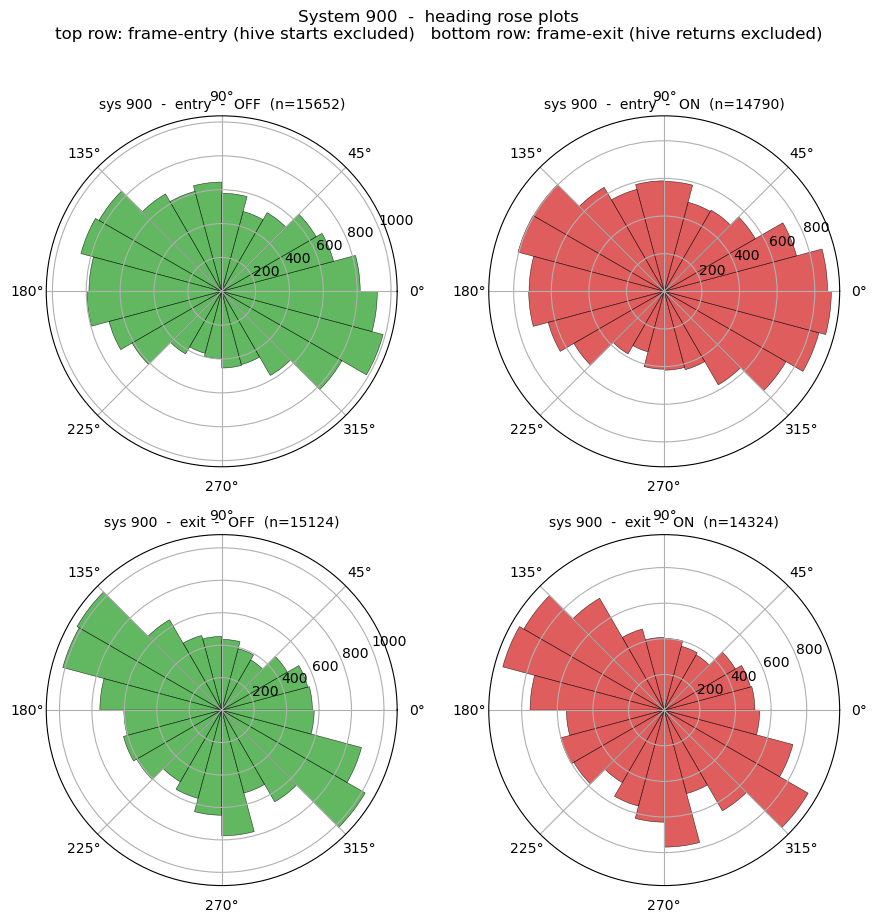

In [25]:
SYSTEM_ID = 900   # change to 939 to inspect the exposed system

def rose_subplot(ax, headings_deg, title, color, n_bins=24):
    """Polar rose histogram with consistent styling."""
    h = headings_deg.dropna()
    if len(h) == 0:
        ax.set_title(f"{title}\n(no data)", fontsize=10)
        return
    bins = np.linspace(-180, 180, n_bins + 1)
    counts, edges = np.histogram(h, bins=bins)
    centers = np.deg2rad((edges[:-1] + edges[1:]) / 2)
    width   = np.deg2rad(np.diff(edges))
    ax.bar(centers, counts, width=width, color=color, alpha=0.75,
           edgecolor="black", linewidth=0.4)
    ax.set_theta_zero_location("E")        # 0 deg = +X (right)
    ax.set_theta_direction(1)              # CCW
    ax.set_title(f"{title}  (n={len(h)})", fontsize=10)


frame_entries = geom[~geom["entry_at_hive"]]
frame_exits   = geom[~geom["exit_at_hive"]]

sub_entry = frame_entries[frame_entries["system_id"] == SYSTEM_ID]
sub_exit  = frame_exits  [frame_exits  ["system_id"] == SYSTEM_ID]

fig, axes = plt.subplots(2, 2, figsize=(9, 9),
                         subplot_kw=dict(polar=True))

# Top row: entry headings
rose_subplot(axes[0, 0],
             sub_entry.loc[sub_entry["condition"] == "OFF", "heading_entry_deg"],
             f"sys {SYSTEM_ID}  -  entry  -  OFF", COLORS["OFF"])
rose_subplot(axes[0, 1],
             sub_entry.loc[sub_entry["condition"] == "ON",  "heading_entry_deg"],
             f"sys {SYSTEM_ID}  -  entry  -  ON",  COLORS["ON"])
# Bottom row: exit headings
rose_subplot(axes[1, 0],
             sub_exit.loc[sub_exit["condition"] == "OFF", "heading_exit_deg"],
             f"sys {SYSTEM_ID}  -  exit  -  OFF", COLORS["OFF"])
rose_subplot(axes[1, 1],
             sub_exit.loc[sub_exit["condition"] == "ON",  "heading_exit_deg"],
             f"sys {SYSTEM_ID}  -  exit  -  ON",  COLORS["ON"])

fig.suptitle(f"System {SYSTEM_ID}  -  heading rose plots\n"
             f"top row: frame-entry (hive starts excluded)   "
             f"bottom row: frame-exit (hive returns excluded)",
             y=1.02)
plt.tight_layout()
plt.show()


## L.5 Is the heading distribution different?

Eyeballing rose plots is unreliable. Two metrics per (system, condition):

- **Mean resultant length R.** R = | mean(e^{iθ}) |, between 0 and 1. R = 1 means all headings perfectly aligned, R = 0 means uniform around the circle. A drop in R when going ON → bees less directional, more disoriented.
- **Mean direction.** atan2 of the mean unit vector — the typical bearing.

A two-sample circular test would be the right thing here, but for now we just print the numbers per condition and let you eyeball whether ON and OFF differ in spread or mean direction.


In [26]:
def circ_stats(headings_deg):
    h = headings_deg.dropna()
    if len(h) == 0:
        return float("nan"), float("nan"), 0
    rad = np.deg2rad(h.values)
    R   = float(np.abs(np.mean(np.exp(1j * rad))))
    mean_dir = float(np.degrees(np.angle(np.mean(np.exp(1j * rad)))))
    return R, mean_dir, len(h)

print("Frame-ENTRY headings (ON vs OFF):")
print(f"  {'sys':>4s} {'cond':>10s} {'mean dir':>12s} {'R':>8s} {'n':>6s}")
for sid in systems:
    sub = frame_entries[frame_entries["system_id"] == sid]
    for cond in ["OFF", "ON"]:
        R, md_, n = circ_stats(sub.loc[sub["condition"] == cond, "heading_entry_deg"])
        print(f"  {sid:>4d} {cond:>10s} {md_:>11.1f}° {R:>8.3f} {n:>6d}")

print("\nFrame-EXIT headings (ON vs OFF):")
print(f"  {'sys':>4s} {'cond':>10s} {'mean dir':>12s} {'R':>8s} {'n':>6s}")
for sid in systems:
    sub = frame_exits[frame_exits["system_id"] == sid]
    for cond in ["OFF", "ON"]:
        R, md_, n = circ_stats(sub.loc[sub["condition"] == cond, "heading_exit_deg"])
        print(f"  {sid:>4d} {cond:>10s} {md_:>11.1f}° {R:>8.3f} {n:>6d}")


Frame-ENTRY headings (ON vs OFF):
   sys       cond     mean dir        R      n
   900        OFF        69.8°    0.051  15652
   900         ON        61.0°    0.061  14790
   939        OFF       136.7°    0.023   8702
   939         ON       118.6°    0.047   9161

Frame-EXIT headings (ON vs OFF):
   sys       cond     mean dir        R      n
   900        OFF      -125.7°    0.073  15124
   900         ON      -132.8°    0.079  14324
   939        OFF      -120.3°    0.055   8675
   939         ON      -101.1°    0.085   9137


## L.6 ΔR permutation test (per system, per heading type)

Tests whether the difference in mean resultant length $\Delta R = R_{\mathrm{ON}} - R_{\mathrm{OFF}}$
is larger in magnitude than expected under the null "ON and OFF bearings come from the same
circular distribution." The null is simulated by shuffling the ON/OFF labels over the
pooled bearings ($5000$ shuffles); the $p$-value is the fraction of shuffles whose
$|\Delta R|$ matches or exceeds the observed $|\Delta R|$. A **negative** $\Delta R$
($R_{\mathrm{ON}} < R_{\mathrm{OFF}}$) is the direction predicted by the directional-confusion
hypothesis. Reports both systems and both heading types in one table.


In [27]:
def perm_test_delta_R(headings_on, headings_off, n_perm=5000, seed=42):
    """Two-sided permutation test on |Delta R| = |R_ON - R_OFF|. Returns
    (R_on, R_off, delta_R, p_perm, n_on, n_off)."""
    on  = np.asarray(headings_on.dropna().values,  dtype=float)
    off = np.asarray(headings_off.dropna().values, dtype=float)
    n_on, n_off = len(on), len(off)
    if n_on < 5 or n_off < 5:
        return float("nan"), float("nan"), float("nan"), float("nan"), n_on, n_off

    def R(angles_deg):
        rad = np.deg2rad(angles_deg)
        return float(np.abs(np.mean(np.exp(1j * rad))))

    R_on, R_off = R(on), R(off)
    obs = R_on - R_off
    pooled = np.concatenate([on, off])
    rng = np.random.default_rng(seed)
    diffs = np.empty(n_perm)
    for k in range(n_perm):
        rng.shuffle(pooled)
        diffs[k] = R(pooled[:n_on]) - R(pooled[n_on:])
    p_perm = float(np.mean(np.abs(diffs) >= np.abs(obs)))
    return R_on, R_off, obs, p_perm, n_on, n_off


# Run for both heading types and both systems
rows = []
for which, src_df, col in [
    ("entry", frame_entries, "heading_entry_deg"),
    ("exit",  frame_exits,   "heading_exit_deg"),
]:
    for sid in systems:
        sub = src_df[src_df["system_id"] == sid]
        on  = sub.loc[sub["condition"] == "ON",  col]
        off = sub.loc[sub["condition"] == "OFF", col]
        R_on, R_off, dR, p, n_on, n_off = perm_test_delta_R(on, off, n_perm=5000)
        rows.append({
            "system":  sid,
            "heading": which,
            "n_ON":    n_on,
            "n_OFF":   n_off,
            "R_ON":    round(R_on,  3) if pd.notna(R_on)  else None,
            "R_OFF":   round(R_off, 3) if pd.notna(R_off) else None,
            "delta_R": round(dR,    3) if pd.notna(dR)    else None,
            "p_perm":  round(p,     4) if pd.notna(p)     else None,
            "sig":     "*" if (pd.notna(p) and p < 0.05) else "",
        })

delta_R_table = pd.DataFrame(rows)
print("Delta R permutation test (5000 shuffles, two-sided)\n")
print("Reading:")
print("  delta_R < 0  -> R_ON < R_OFF -> more dispersion under ON")
print("                  (consistent with directional-confusion hypothesis)")
print("  delta_R > 0  -> R_ON > R_OFF -> less dispersion under ON")
print("  Across 4 tests, BH-adjusted significance at q=0.05 needs raw p < ~0.0125\n")
print(delta_R_table.to_string(index=False))


Delta R permutation test (5000 shuffles, two-sided)

Reading:
  delta_R < 0  -> R_ON < R_OFF -> more dispersion under ON
                  (consistent with directional-confusion hypothesis)
  delta_R > 0  -> R_ON > R_OFF -> less dispersion under ON
  Across 4 tests, BH-adjusted significance at q=0.05 needs raw p < ~0.0125

 system heading  n_ON  n_OFF  R_ON  R_OFF  delta_R  p_perm sig
    900   entry 14790  15652 0.061  0.051    0.011  0.1526    
    939   entry  9161   8702 0.047  0.023    0.024  0.0196   *
    900    exit 14324  15124 0.079  0.073    0.005  0.4592    
    939    exit  9137   8675 0.085  0.055    0.030  0.0034   *


# Section M — Day 1 vs Day 3 ON (accumulation / habituation)

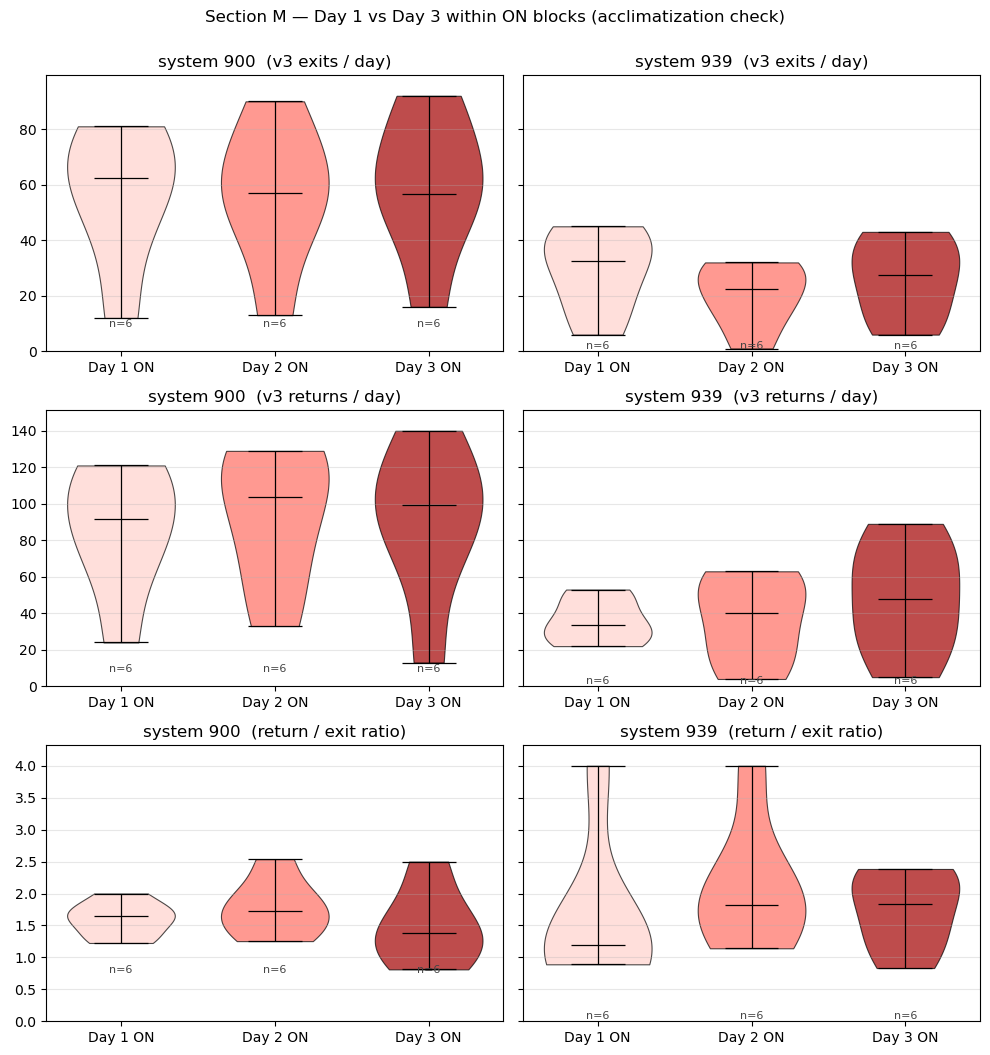


Day 1 ON vs Day 3 ON (Mann-Whitney U, two-sided):
 system  indicator                     n_d1  n_d3    med_d1   med_d3    Δ(d3-d1)         p
    900  v3 exits / day                   6     6     62.50    56.50       -6.00    1.0000
    900  v3 returns / day                 6     6     91.50    99.50       +8.00    0.8182
    900  return / exit ratio              6     6      1.66     1.38       -0.28    0.6884
    939  v3 exits / day                   6     6     32.50    27.50       -5.00    0.7483
    939  v3 returns / day                 6     6     33.50    48.00      +14.50    0.5887
    939  return / exit ratio              6     6      1.20     1.83       +0.64    0.3095

Interpretation:
  - Δ(d3-d1) < 0  ⇒ Day 3 below Day 1  ⇒ acclimatization (consistent with acute impairment hypothesis)
  - Δ(d3-d1) > 0  ⇒ Day 3 above Day 1  ⇒ habituation OR within-block order effect
                                          (inconsistent with simple 5G-impairment story)
  - p > 0.10 with sma

In [28]:

# Section M — Day 1 ON vs Day 3 ON (accumulation / habituation check)
# ---------------------------------------------------------------------------
# Within each 3-day ON block, label each day by its position (1, 2, 3).
# If 5G accumulates impairment, Day 3 < Day 1.
# If bees habituate (or there\'s an unrelated within-block order effect),
# Day 3 > Day 1.
# A flat result means no within-block trend.

def day_in_on_block(date_like):
    """Position within a 3-day ON block (1, 2, or 3), or None if not ON."""
    d = pd.Timestamp(date_like)
    if d < CYCLE_ANCHOR:
        return None
    days_since = (d - CYCLE_ANCHOR).days
    cycle_pos  = days_since % CYCLE_LEN
    if cycle_pos < CYCLE_ON_DAYS:
        return int(cycle_pos) + 1   # 1, 2, 3
    return None


on_days = daily[daily["condition"] == "ON"].copy()
on_days["day_in_block"] = on_days["date"].apply(day_in_on_block)
on_days = on_days.dropna(subset=["day_in_block"])
on_days["day_in_block"] = on_days["day_in_block"].astype(int)

INDICATORS_M = [
    ("n_exit_v3",     "v3 exits / day",     0),
    ("n_return_v3",   "v3 returns / day",   0),
    ("re_ratio_v3",   "return / exit ratio", 0),
]

DAY_ORDER  = [1, 2, 3]
DAY_LABELS = ["Day 1 ON", "Day 2 ON", "Day 3 ON"]
DAY_COLORS = ["#ffd2cc", "#ff6e63", "#a30000"]   # light → dark red

# ---- Boxplots: Day 1 / Day 2 / Day 3, y-axes shared per indicator ----
fig, axes = plt.subplots(len(INDICATORS_M), len(SYSTEMS),
                         figsize=(5 * len(SYSTEMS), 3.5 * len(INDICATORS_M)),
                         sharey="row", squeeze=False)
for r, (col, label, lo) in enumerate(INDICATORS_M):
    row_max = 0
    for sys_id in SYSTEMS:
        sub = on_days[on_days["system_id"] == sys_id]
        if not sub.empty:
            row_max = max(row_max, sub[col].max(skipna=True) or 0)
    for c, sys_id in enumerate(SYSTEMS):
        ax = axes[r, c]
        sub = on_days[on_days["system_id"] == sys_id]
        groups = [sub.loc[sub["day_in_block"] == d, col].dropna().values
                  for d in DAY_ORDER]
        _violin_group(ax, groups, DAY_LABELS, DAY_COLORS, alpha=0.7)
        ax.set_title(f"system {sys_id}  ({label})")
        ax.set_ylim(lo, row_max * 1.08 if row_max > 0 else 1)
        ax.grid(axis="y", alpha=0.3)

plt.suptitle("Section M — Day 1 vs Day 3 within ON blocks (acclimatization check)",
             fontsize=12, y=1.0)
plt.tight_layout()
plt.show()


# ---- Mann-Whitney U: Day 1 vs Day 3 per (system × indicator) ----
print()
print("Day 1 ON vs Day 3 ON (Mann-Whitney U, two-sided):")
print(f"{'system':>7s}  {'indicator':<28s} {'n_d1':>5s} {'n_d3':>5s}  "
      f"{'med_d1':>8s} {'med_d3':>8s}  {'Δ(d3-d1)':>10s}  {'p':>8s}")
rows_m = []
for sys_id in SYSTEMS:
    sub = on_days[on_days["system_id"] == sys_id]
    for col, label, _ in INDICATORS_M:
        d1 = sub.loc[sub["day_in_block"] == 1, col].dropna()
        d3 = sub.loc[sub["day_in_block"] == 3, col].dropna()
        if len(d1) < 2 or len(d3) < 2:
            print(f"  {sys_id:>5d}  {label:<28s} n too small")
            continue
        u, p = stats.mannwhitneyu(d1, d3, alternative="two-sided")
        delta = float(d3.median() - d1.median())
        print(f"  {sys_id:>5d}  {label:<28s} {len(d1):>5d} {len(d3):>5d}  "
              f"{d1.median():>8.2f} {d3.median():>8.2f}  {delta:>+10.2f}  {p:>8.4f}")
        rows_m.append((sys_id, label, len(d1), len(d3),
                        float(d1.median()), float(d3.median()), delta, float(p)))

print()
print("Interpretation:")
print("  - Δ(d3-d1) < 0  ⇒ Day 3 below Day 1  ⇒ acclimatization (consistent with acute impairment hypothesis)")
print("  - Δ(d3-d1) > 0  ⇒ Day 3 above Day 1  ⇒ habituation OR within-block order effect")
print("                                          (inconsistent with simple 5G-impairment story)")
print("  - p > 0.10 with small n ⇒ no detectable within-block trend; treat block as a unit.")


# Section N — Day 3 OFF vs Day 1 ON (cross-block carryover)

Day-3 OFF days: ['2026-04-28', '2026-05-04', '2026-05-10', '2026-05-16', '2026-05-22', '2026-05-28']
Day-1 ON days:  ['2026-04-23', '2026-04-29', '2026-05-05', '2026-05-11', '2026-05-17', '2026-05-23']


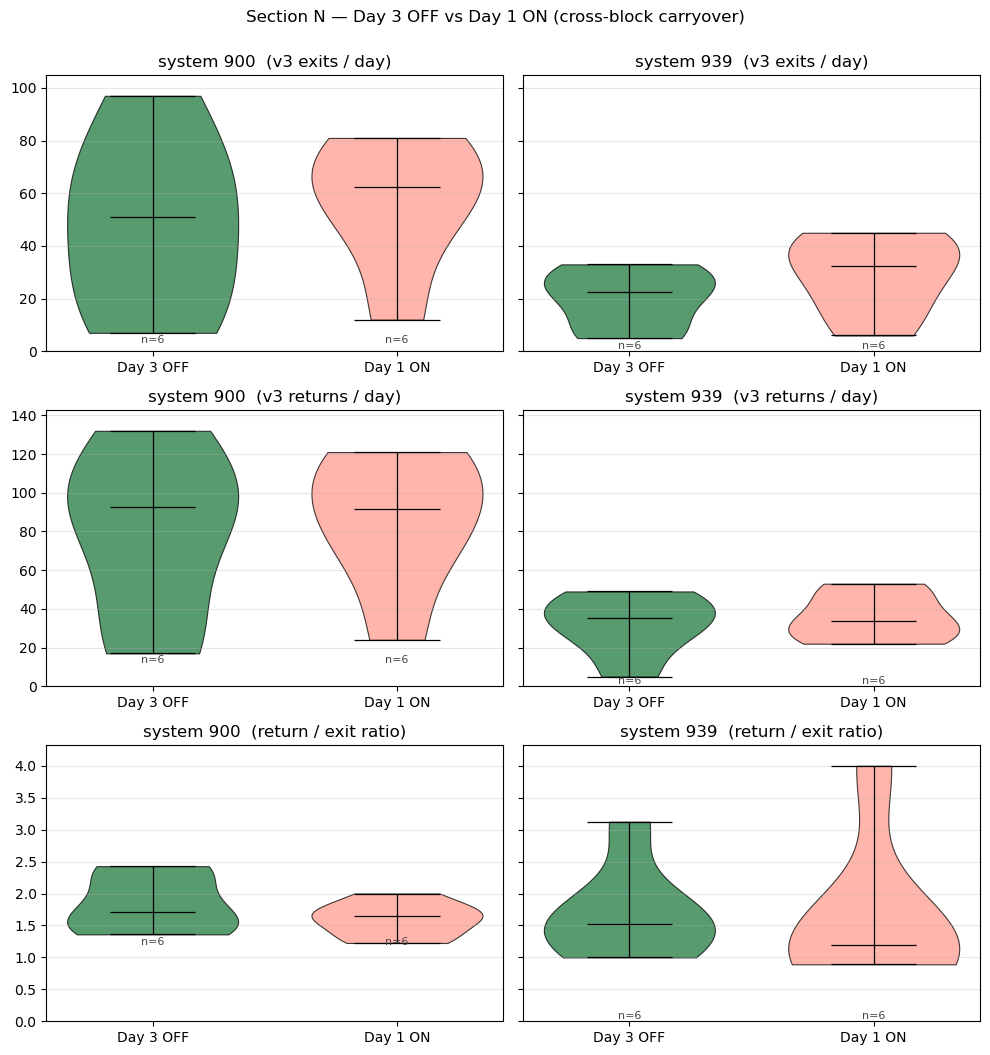


Day 3 OFF vs Day 1 ON (Mann-Whitney U, two-sided):
 system  indicator                    n_d3off n_d1on  med_d3off  med_d1on   Δ(d1on-d3off)         p
    900  v3 exits / day                     6      6      51.00     62.50          +11.50    0.8182
    900  v3 returns / day                   6      6      92.50     91.50           -1.00    0.8182
    900  return / exit ratio                6      6       1.71      1.66           -0.06    0.4848
    939  v3 exits / day                     6      6      22.50     32.50          +10.00    0.3095
    939  v3 returns / day                   6      6      35.50     33.50           -2.00    0.9372
    939  return / exit ratio                6      6       1.52      1.20           -0.33    0.2403

Interpretation:
  - p > 0.10  ⇒ Day 3 OFF and Day 1 ON are indistinguishable. The
                experimental contrast is clean: bees enter each ON
                block from the same BASELINE they left.
  - p < 0.05  ⇒ a sharp shift at the OFF→O

In [29]:

# Section N — Day 3 OFF vs Day 1 ON (cross-block carryover)
# ---------------------------------------------------------------------------
# Different question from Section M: does activity on the LAST day of an OFF
# block resemble activity on the FIRST day of the next ON block? If yes →
# the bees came into the ON block already at their "OFF level" and any later
# shift is a true ON effect. If no (Day 1 ON already different from Day 3
# OFF) → there\'s a carryover from the previous OFF or an instantaneous shift
# at the transition. With ~3-4 such transitions in this dataset, the test is
# descriptive rather than statistically powered.

def day_in_off_block(date_like):
    """Position within a 3-day OFF block (1, 2, or 3), or None if not OFF."""
    d = pd.Timestamp(date_like)
    if d < CYCLE_ANCHOR:
        return None
    days_since = (d - CYCLE_ANCHOR).days
    cycle_pos  = days_since % CYCLE_LEN
    if cycle_pos >= CYCLE_ON_DAYS:
        return int(cycle_pos - CYCLE_ON_DAYS) + 1   # 1, 2, 3 within OFF block
    return None


def reuse_day_in_on_block(date_like):
    d = pd.Timestamp(date_like)
    if d < CYCLE_ANCHOR:
        return None
    days_since = (d - CYCLE_ANCHOR).days
    cycle_pos  = days_since % CYCLE_LEN
    if cycle_pos < CYCLE_ON_DAYS:
        return int(cycle_pos) + 1
    return None


daily["day_in_off_block"] = daily["date"].apply(day_in_off_block)
daily["day_in_on_block"]  = daily["date"].apply(reuse_day_in_on_block)

day3_off = daily[daily["day_in_off_block"] == 3].copy()
day1_on  = daily[daily["day_in_on_block"]  == 1].copy()

print(f"Day-3 OFF days: {sorted(day3_off['date'].unique().tolist())}")
print(f"Day-1 ON days:  {sorted(day1_on['date'].unique().tolist())}")

INDICATORS_N = [
    ("n_exit_v3",   "v3 exits / day",     0),
    ("n_return_v3", "v3 returns / day",   0),
    ("re_ratio_v3", "return / exit ratio", 0),
]
N_ORDER  = ["Day 3 OFF", "Day 1 ON"]
N_COLORS = {"Day 3 OFF": "#1f7a3f", "Day 1 ON": "#ff9c8f"}   # dark green → light red

# ---- Boxplots side-by-side, y-axes shared per indicator ----
fig, axes = plt.subplots(len(INDICATORS_N), len(SYSTEMS),
                         figsize=(5 * len(SYSTEMS), 3.5 * len(INDICATORS_N)),
                         sharey="row", squeeze=False)
for r, (col, label, lo) in enumerate(INDICATORS_N):
    row_max = 0
    for sys_id in SYSTEMS:
        for src_df in (day3_off, day1_on):
            sub = src_df[src_df["system_id"] == sys_id]
            if not sub.empty:
                row_max = max(row_max, sub[col].max(skipna=True) or 0)
    for c, sys_id in enumerate(SYSTEMS):
        ax = axes[r, c]
        d3o = day3_off.loc[day3_off["system_id"] == sys_id, col].dropna().values
        d1n = day1_on.loc[day1_on["system_id"]  == sys_id, col].dropna().values
        _violin_group(ax, [d3o, d1n], N_ORDER, N_COLORS, alpha=0.75)
        ax.set_title(f"system {sys_id}  ({label})")
        ax.set_ylim(lo, row_max * 1.08 if row_max > 0 else 1)
        ax.grid(axis="y", alpha=0.3)
plt.suptitle("Section N — Day 3 OFF vs Day 1 ON (cross-block carryover)",
             fontsize=12, y=1.0)
plt.tight_layout()
plt.show()

# ---- Mann-Whitney U per (system × indicator) ----
print()
print("Day 3 OFF vs Day 1 ON (Mann-Whitney U, two-sided):")
print(f"{'system':>7s}  {'indicator':<28s} {'n_d3off':>7s} {'n_d1on':>6s}  "
      f"{'med_d3off':>9s} {'med_d1on':>9s}  {'Δ(d1on-d3off)':>14s}  {'p':>8s}")
for sys_id in SYSTEMS:
    for col, label, _ in INDICATORS_N:
        d3o = day3_off.loc[day3_off["system_id"] == sys_id, col].dropna()
        d1n = day1_on.loc[day1_on["system_id"]  == sys_id, col].dropna()
        if len(d3o) < 2 or len(d1n) < 2:
            print(f"  {sys_id:>5d}  {label:<28s} n too small (need ≥2 in each group)")
            continue
        u, p = stats.mannwhitneyu(d3o, d1n, alternative="two-sided")
        delta = float(d1n.median() - d3o.median())
        print(f"  {sys_id:>5d}  {label:<28s} {len(d3o):>7d} {len(d1n):>6d}  "
              f"{d3o.median():>9.2f} {d1n.median():>9.2f}  {delta:>+14.2f}  {p:>8.4f}")

print()
print("Interpretation:")
print("  - p > 0.10  ⇒ Day 3 OFF and Day 1 ON are indistinguishable. The")
print("                experimental contrast is clean: bees enter each ON")
print("                block from the same BASELINE they left.")
print("  - p < 0.05  ⇒ a sharp shift at the OFF→ON transition. Either an")
print("                acute response to the equipment turning on, or a")
print("                day-1-specific carryover from the previous OFF block.")
print("                With n≈3-4 per side, formal significance is hard to")
print("                reach; treat this section as descriptive.")


# Section FV — Flower-visit indicators (secondary modality)

Flower-visit data: (70, 9)  (2026-04-23 → 2026-05-28)

Condition coverage (days with flower-visit data):
condition  OFF  ON
system_id         
900         17  18
939         17  18


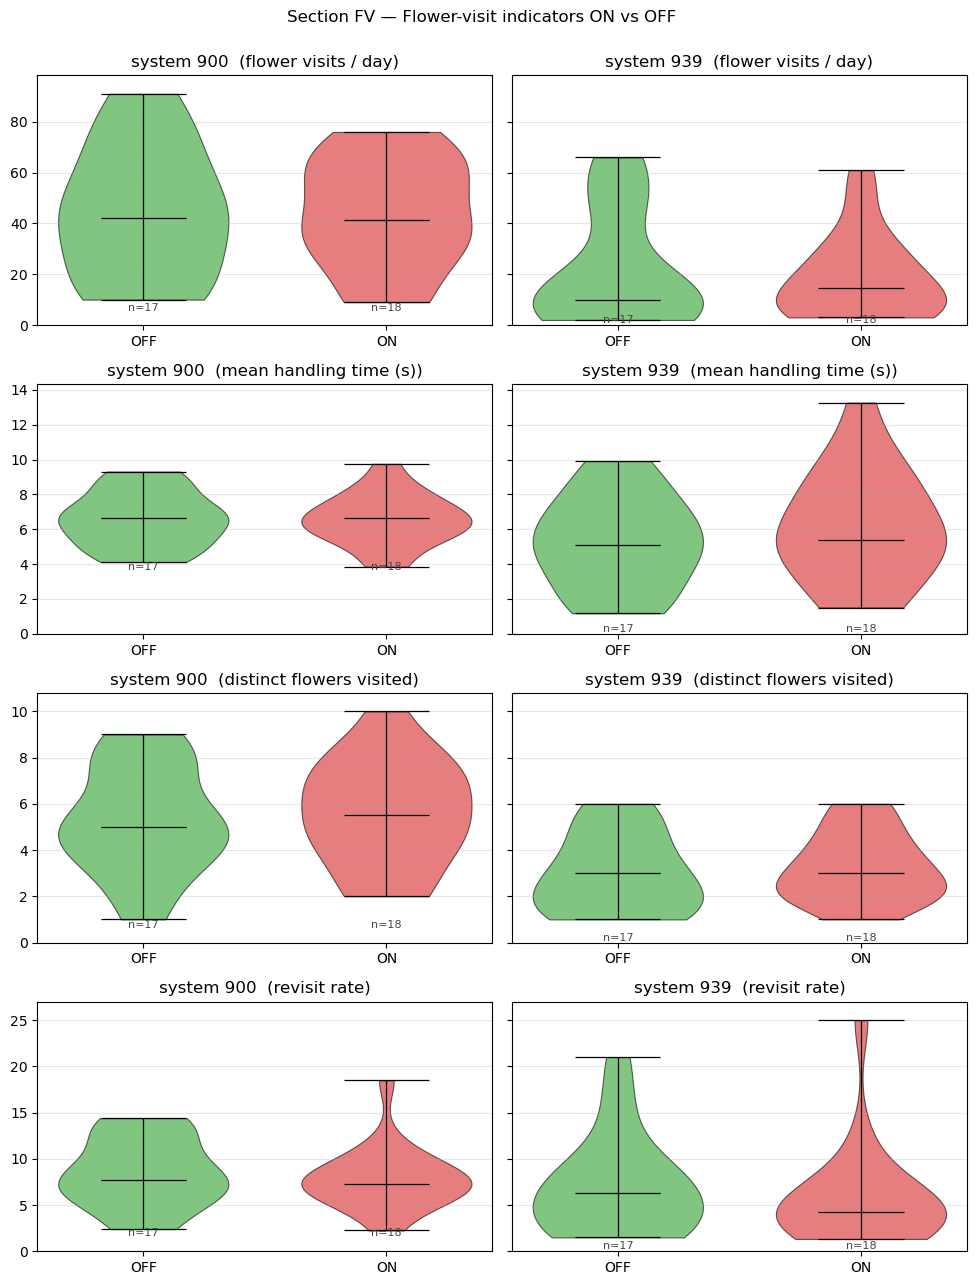


Flower-visit indicators (ON vs OFF) per system:
 system                indicator  n_OFF  n_ON  med_OFF  med_ON      r  p_uncorr   p_BH
    900      flower visits / day     17    18    42.00   41.50  0.039    0.8559 0.9605
    900   mean handling time (s)     17    18     6.65    6.62  0.013    0.9605 0.9605
    900 distinct flowers visited     17    18     5.00    5.50 -0.056    0.7889 0.9605
    900             revisit rate     17    18     7.67    7.31  0.131    0.5198 0.9605
    939      flower visits / day     17    18    10.00   14.50  0.023    0.9210 0.9210
    939   mean handling time (s)     17    18     5.07    5.40 -0.157    0.4380 0.7111
    939 distinct flowers visited     17    18     3.00    3.00 -0.124    0.5333 0.7111
    939             revisit rate     17    18     6.33    4.25  0.170    0.3996 0.7111

Survives BH per-system at q=0.05:  0 / 8

Reading: if 0/8 survive BH, the flower-visit modality returns the
same null as the activity modality — strengthens the overal

,system,indicator,n_OFF,n_ON,med_OFF,med_ON,r,p_uncorr,p_BH
0,900,flower visits / day,17,18,42.00,41.50,0.039,0.8559,0.9605
1,900,mean handling time (s),17,18,6.65,6.62,0.013,0.9605,0.9605
2,900,distinct flowers visited,17,18,5.00,5.50,-0.056,0.7889,0.9605
3,900,revisit rate,17,18,7.67,7.31,0.131,0.5198,0.9605
4,939,flower visits / day,17,18,10.00,14.50,0.023,0.9210,0.9210
5,939,mean handling time (s),17,18,5.07,5.40,-0.157,0.4380,0.7111
6,939,distinct flowers visited,17,18,3.00,3.00,-0.124,0.5333,0.7111
7,939,revisit rate,17,18,6.33,4.25,0.170,0.3996,0.7111


In [30]:

# Section FV — Flower-visit indicators (secondary endpoint)
# ---------------------------------------------------------------------------
# Flower visits are a finer-grained behavioural measure than gross activity
# counts. A bumblebee whose total flight count is unchanged could still
# spend longer at each flower (impaired motor / cognition) or visit fewer
# distinct flowers (impaired exploration / memory). Adding these gives a
# second independent test of the same hypothesis.
#
# Source: flower_visit_summary.csv (produced by flower_visit_pipeline.ipynb)

from scipy.stats import false_discovery_control

FV_PATH = Path("data/multi_day") / "flower_visit_summary.csv"

if not FV_PATH.exists():
    print(f"!!! {FV_PATH} not found — run flower_visit_pipeline.ipynb first")
else:
    fv = pd.read_csv(FV_PATH)
    fv["date"]      = pd.to_datetime(fv["date"]).dt.strftime("%Y-%m-%d")
    fv["condition"] = fv["date"].apply(condition_for)

    # Restrict to the experimental window (cycle anchor onward) to match the
    # rest of the analysis. BASELINE rows are kept in the raw
    # flower_visits.csv detection output but excluded here so that the FV
    # ON/OFF comparison uses the same date range as the indicator dashboard.
    fv = fv[fv["date"] >= "2026-04-23"].reset_index(drop=True)

    # Restrict to system 900 only — sys 939 is shown elsewhere in the
    # dashboard for transparency but not used as a foreground comparator
    # because of the data-integrity issues documented in §3.5.
# Include both system 900 and 939
    fv = fv[fv["system_id"].isin([900, 939])].reset_index(drop=True)
    
    print(f"Flower-visit data: {fv.shape}  ({fv['date'].min()} → {fv['date'].max()})")
    print()
    print("Condition coverage (days with flower-visit data):")
    print(fv.groupby(["system_id", "condition"]).size().unstack(fill_value=0))

    FV_METRICS = [
        ("n_visits",             "flower visits / day"),
        ("mean_handling_time_s", "mean handling time (s)"),
        ("n_distinct_flowers",   "distinct flowers visited"),
        ("revisit_rate",         "revisit rate"),
    ]
    FV_ORDER  = ["OFF", "ON"]
    FV_COLORS = {"OFF": "tab:green", "ON": "tab:red"}

    # ---- Boxplots ON vs OFF, y-axes shared per indicator ----
    fig, axes = plt.subplots(len(FV_METRICS), len(SYSTEMS),
                             figsize=(5 * len(SYSTEMS), 3.2 * len(FV_METRICS)),
                             sharey="row", squeeze=False)
    for r, (col, label) in enumerate(FV_METRICS):
        row_max = 0
        for sys_id in SYSTEMS:
            sub = fv[(fv["system_id"] == sys_id) & fv["condition"].isin(FV_ORDER)]
            if not sub.empty:
                row_max = max(row_max, sub[col].max(skipna=True) or 0)
        for c, sys_id in enumerate(SYSTEMS):
            ax = axes[r, c]
            sub = fv[(fv["system_id"] == sys_id) & fv["condition"].isin(FV_ORDER)]
            groups = [sub.loc[sub["condition"] == k, col].dropna().values
                      for k in FV_ORDER]
            _violin_group(ax, groups, FV_ORDER, FV_COLORS, alpha=0.6)
            ax.set_title(f"system {sys_id}  ({label})")
            ax.set_ylim(0, row_max * 1.08 if row_max > 0 else 1)
            ax.grid(axis="y", alpha=0.3)
    plt.suptitle("Section FV — Flower-visit indicators ON vs OFF",
                 fontsize=12, y=1.0)
    plt.tight_layout()
    plt.show()

    # ---- Stat tests: Mann-Whitney + rank-biserial + BH per system ----
    rows = []
    for sys_id in SYSTEMS:
        sub = fv[(fv["system_id"] == sys_id) & fv["condition"].isin(FV_ORDER)]
        for col, label in FV_METRICS:
            on  = sub.loc[sub["condition"] == "ON",  col].dropna()
            off = sub.loc[sub["condition"] == "OFF", col].dropna()
            if len(on) < 2 or len(off) < 2:
                rows.append({"system": sys_id, "indicator": label,
                              "n_OFF": len(off), "n_ON": len(on),
                              "med_OFF": np.nan, "med_ON": np.nan,
                              "r": np.nan, "p_uncorr": np.nan, "p_BH": np.nan})
                continue
            u, p = stats.mannwhitneyu(on, off, alternative="two-sided")
            r = 1.0 - (2.0 * u) / (len(on) * len(off))
            rows.append({
                "system":   sys_id,
                "indicator": label,
                "n_OFF":     len(off),
                "n_ON":      len(on),
                "med_OFF":   round(float(off.median()), 2),
                "med_ON":    round(float(on.median()),  2),
                "r":         round(float(r), 3),
                "p_uncorr":  round(float(p), 4),
            })

    fv_table = pd.DataFrame(rows)
    if not fv_table.empty:
        for sys_id in SYSTEMS:
            mask = fv_table["system"] == sys_id
            ps = fv_table.loc[mask, "p_uncorr"].tolist()
            valid = [p for p in ps if not pd.isna(p)]
            if valid:
                bh = false_discovery_control(valid)
                bh_it = iter(bh)
                fv_table.loc[mask, "p_BH"] = [
                    round(float(next(bh_it)), 4) if not pd.isna(p) else np.nan
                    for p in ps
                ]
        print()
        print("Flower-visit indicators (ON vs OFF) per system:")
        print(fv_table.to_string(index=False))
        print()
        n_surv = int(fv_table["p_BH"].lt(0.05).sum())
        print(f"Survives BH per-system at q=0.05:  {n_surv} / {len(fv_table)}")
        print()
        print("Reading: if 0/8 survive BH, the flower-visit modality returns the")
        print("same null as the activity modality — strengthens the overall null.")
        print("If any survive, that\'s a finer-grained finding worth featuring even")
        print("when gross activity counts show no effect.")

fv_table

## FV count summary (report-ready numbers)

Loads the raw \texttt{flower\_visits.csv} (one row per detected visit)
and prints the totals, the within/cross-track split with percentages,
and the duration statistics that populate the §4.3 prose.

In [ ]:
# ─── FV count summary: report-ready totals + within/cross split + durations ───
FVISITS_PATH = Path("data/multi_day") / "flower_visits.csv"
if not FVISITS_PATH.exists():
    print(f"!!! {FVISITS_PATH} not found — run flower_visit_pipeline.ipynb first")
else:
    fv_raw = pd.read_csv(FVISITS_PATH)
    fv_raw = fv_raw[fv_raw["system_id"] == 900].reset_index(drop=True)

    def summarise(df, label):
        n_visits    = len(df)
        n_within    = int((df["source"] == "within").sum())
        n_cross     = int((df["source"] == "cross").sum())
        if n_visits == 0:
            print(f"\n--- {label}: no visits ---"); return
        pct_within  = 100 * n_within / n_visits
        pct_cross   = 100 * n_cross  / n_visits
        n_dayrows   = df.groupby(["date", "system_id"]).size().shape[0]
        date_min, date_max = df["date"].min(), df["date"].max()
        med_dur     = float(df["duration_s"].median())
        q25, q75    = float(df["duration_s"].quantile(0.25)), float(df["duration_s"].quantile(0.75))
        print(f"\n--- {label} ---")
        print(f"  Date range          : {date_min}  -->  {date_max}")
        print(f"  Day-system rows     : {n_dayrows}")
        print(f"  Total visits        : {n_visits}")
        print(f"  Within-track type   : {n_within:4d}  ({pct_within:.1f} %)")
        print(f"  Cross-track type    : {n_cross:4d}  ({pct_cross:.1f} %)")
        print(f"  Visit duration      : median {med_dur:.2f} s, IQR {q25:.2f}-{q75:.2f} s")

    # Two summaries, so you can pick whichever matches the report sentence:
    #   (a) full detector output, including BASELINE -- matches §4.3 as currently written
    #   (b) experimental window only (>= 2026-04-23) -- matches the FV ON-vs-OFF analysis above
    summarise(fv_raw, "Sys 900 — full detector output (all dates incl. BASELINE)")
    summarise(fv_raw[fv_raw["date"] >= "2026-04-23"],
              "Sys 900 — experimental window only (>= 2026-04-23)")



--- Sys 900 — full detector output (all dates incl. BASELINE) ---
  Date range          : 2026-04-13  -->  2026-05-28
  Day-system rows     : 45
  Total visits        : 2450
  Within-track type   :  981  (40.0 %)
  Cross-track type    : 1469  (60.0 %)
  Visit duration      : median 3.19 s, IQR 1.50-10.74 s

--- Sys 900 — experimental window only (>= 2026-04-23) ---
  Date range          : 2026-04-23  -->  2026-05-28
  Day-system rows     : 35
  Total visits        : 1542
  Within-track type   :  663  (43.0 %)
  Cross-track type    :  879  (57.0 %)
  Visit duration      : median 2.93 s, IQR 1.44-10.39 s


### FV count


In [ ]:
import pandas as pd

# 1. Load the dataset
df = pd.read_csv(FV_PATH)
display(df)

# 2. Filter the DataFrame for system 900 and the specific date range
filtered_df = df[
    (df['system_id'] == 900) & 
    (df['date'] >= '2026-04-23') & 
    (df['date'] <= '2026-05-28')
]

# 3. Sum the n_visits column
total_visits = filtered_df['n_visits'].sum()

print("Total visits:", total_visits)


,date,system_id,n_visits,mean_handling_time_s,median_handling_time_s,total_visit_time_s,n_distinct_flowers,revisit_rate
0,2026-04-13,900,30,3.532315,1.530035,105.969443,6,5.000000
1,2026-04-14,900,56,6.551293,3.177031,366.872396,7,8.000000
2,2026-04-15,900,87,6.396789,2.642387,556.520625,10,8.700000
3,2026-04-16,900,46,7.019663,2.870990,322.904504,5,9.200000
4,2026-04-17,900,85,8.229549,3.817352,699.511661,7,12.142857
...,...,...,...,...,...,...,...,...
77,2026-05-23,939,7,2.159601,1.540818,15.117208,2,3.500000
78,2026-05-24,939,10,5.662698,1.340553,56.626984,3,3.333333
79,2026-05-25,939,4,1.508283,1.577908,6.033133,3,1.333333
80,2026-05-27,939,6,1.784950,1.535518,10.709703,4,1.500000


Total visits: 1542


# Section O — Day-level dose-response (dBm vs indicator)

Spearman rank correlation between daily mean transmitted power (`mean_dbm` in
`indicators_daily.csv`) and each behavioural indicator, restricted to ON days.
This is the day-level proxy for the originally pre-registered hour-resolution
dose-response. Day-level results inherit weather and day-of-cycle covariates
and should be read as exploratory, not as a clean dose-response.


In [ ]:
import numpy as np, pandas as pd
from math import erf, sqrt

# Reload indicators_daily with greenhouse-temp-friendly date type and
# add the two flower-visit indicators from flower_visit_summary.csv
_DATA = Path("data/multi_day")
ind_o = pd.read_csv(_DATA / "indicators_daily.csv")
fv_o  = pd.read_csv(_DATA / "flower_visit_summary.csv")[
            ["date","system_id","mean_handling_time_s","n_distinct_flowers"]]
ind_o = (ind_o.drop(columns=[c for c in ["mean_handling_time_s","n_distinct_flowers"]
                              if c in ind_o.columns])
              .merge(fv_o, on=["date","system_id"], how="left"))

# Apply the same condition labels used elsewhere (5/26 EXCLUDED, 5/29 OFF)
_ANCHOR = pd.Timestamp("2026-04-23")
_EXCL   = {pd.Timestamp("2026-05-26")}
_OFFOV  = {pd.Timestamp("2026-05-29")}
def _label(d):
    d = pd.Timestamp(d)
    if d in _EXCL:  return "EXCLUDED"
    if d in _OFFOV: return "OFF"
    if d < _ANCHOR: return "BASELINE"
    return "ON" if ((d - _ANCHOR).days // 3) % 2 == 0 else "OFF"
ind_o["condition"] = pd.to_datetime(ind_o["date"]).apply(_label)


def _spearman(x, y):
    x = np.asarray(x, dtype=float); y = np.asarray(y, dtype=float)
    m = ~(np.isnan(x) | np.isnan(y)); x, y = x[m], y[m]; n = len(x)
    if n < 3: return np.nan, np.nan, n
    rx = pd.Series(x).rank().values; ry = pd.Series(y).rank().values
    rho = float(np.corrcoef(rx, ry)[0, 1])
    if abs(rho) >= 1.0:
        p = 0.0
    else:
        t = rho * np.sqrt((n - 2) / (1 - rho ** 2))
        p = 2 * (1 - 0.5 * (1 + erf(abs(t) / np.sqrt(2))))
    return rho, p, n


DOSE_INDS = [
    ("n_v3",                  "v3 exits / day"),
    ("n_returns",             "v3 returns / day"),
    ("re_ratio_v3",           "return / exit ratio"),
    ("path_tortuosity",       "median tortuosity"),
    ("ifi_cv",                "IFI CV"),
    ("mean_handling_time_s",  "mean handling time"),
    ("n_distinct_flowers",    "distinct flowers"),
]

rows = []
for sid in sorted(ind_o["system_id"].unique()):
    sub = ind_o[(ind_o.system_id == sid)
                & (ind_o.condition == "ON")
                & ind_o["mean_dbm"].notna()]
    n_on = len(sub)
    for col, label in DOSE_INDS:
        if col not in sub.columns:
            rho, p, n = np.nan, np.nan, 0
        else:
            rho, p, n = _spearman(sub["mean_dbm"], sub[col])
        rows.append({"system": sid, "indicator": label, "n_ON_with_dBm": n_on,
                     "rho": rho, "p": p, "flag": "*" if pd.notna(rho) and abs(rho) >= 0.3 else ""})
dose_df = pd.DataFrame(rows)
with pd.option_context("display.max_rows", None, "display.width", 140):
    print("Section O — Spearman(mean_dbm, indicator) on ON days, per system")
    print(dose_df.round(3).to_string(index=False))


Section O — Spearman(mean_dbm, indicator) on ON days, per system
 system           indicator  n_ON_with_dBm    rho     p flag
    900      v3 exits / day             18  0.559 0.007    *
    900    v3 returns / day             18  0.548 0.009    *
    900 return / exit ratio             18  0.023 0.928     
    900   median tortuosity             18 -0.711 0.000    *
    900              IFI CV             18  0.201 0.411     
    900  mean handling time             18  0.591 0.003    *
    900    distinct flowers             18  0.249 0.303     
    939      v3 exits / day             12  0.452 0.109    *
    939    v3 returns / day             12  0.504 0.065    *
    939 return / exit ratio             12  0.517 0.056    *
    939   median tortuosity             12 -0.503 0.065    *
    939              IFI CV             12  0.217 0.483     
    939  mean handling time             12 -0.266 0.383     
    939    distinct flowers             12  0.575 0.026    *


# Section FII — Composite Foraging Impairment Index

The six pre-registered indicators are sign-aligned so that a positive value
indicates the impairment direction, $z$-scored against the within-system
BASELINE+OFF reference distribution, and averaged. ON vs OFF is tested per
system and pooled, with a $5000$-resample bootstrap on the pooled
rank-biserial $r$.


In [152]:
# Sign-aligned columns (negated where higher-is-healthier)
ind_o["neg_exit_count"] = -ind_o["n_v3"]
ind_o["neg_re_ratio"]   = -ind_o["re_ratio_v3"]
ind_o["neg_n_distinct"] = -ind_o["n_distinct_flowers"]

FII_INDS = ["neg_exit_count", "neg_re_ratio", "path_tortuosity",
            "ifi_cv", "mean_handling_time_s", "neg_n_distinct"]

# Per-system z-score against BASELINE+OFF (treatment-free reference)
_ref = ind_o[ind_o["condition"].isin(["BASELINE", "OFF"])]
_z_params = {sid: (g[FII_INDS].mean(), g[FII_INDS].std())
             for sid, g in _ref.groupby("system_id")}

def _fii(row):
    mu, sd = _z_params[row.system_id]
    return ((row[FII_INDS] - mu) / sd).mean()
ind_o["FII"] = ind_o.apply(_fii, axis=1)


def _mwu(a, b):
    a = np.asarray(a, dtype=float); b = np.asarray(b, dtype=float)
    na, nb = len(a), len(b)
    if na < 2 or nb < 2: return np.nan, np.nan, np.nan
    ranks = pd.Series(np.concatenate([a, b])).rank()
    Ra = ranks[:na].sum(); U1 = Ra - na * (na + 1) / 2; U2 = na * nb - U1
    U = min(U1, U2); mu = na * nb / 2; sd = np.sqrt(na * nb * (na + nb + 1) / 12)
    z = (U - mu) / sd
    p = 2 * (1 - 0.5 * (1 + erf(abs(z) / np.sqrt(2))))
    r = 1 - 2 * U / (na * nb)
    return U, p, r


print("FII (sign-aligned z-average across 6 indicators)")
print("-" * 70)
for sid in sorted(ind_o["system_id"].unique()):
    on  = ind_o[(ind_o.system_id == sid) & (ind_o.condition == "ON")]["FII"].dropna()
    off = ind_o[(ind_o.system_id == sid) & (ind_o.condition == "OFF")]["FII"].dropna()
    base = ind_o[(ind_o.system_id == sid) & (ind_o.condition == "BASELINE")]["FII"].dropna()
    U, p, r = _mwu(on, off)
    print(f"  sys {sid}: BASELINE med={base.median():+.3f} (n={len(base)})  "
          f"OFF med={off.median():+.3f} (n={len(off)})  "
          f"ON med={on.median():+.3f} (n={len(on)})")
    print(f"    MWU ON vs OFF: U={U}  p={p:.3f}  r={r:+.3f}")

on_pool  = ind_o[ind_o.condition == "ON"]["FII"].dropna()
off_pool = ind_o[ind_o.condition == "OFF"]["FII"].dropna()
U, p, r = _mwu(on_pool, off_pool)
print(f"\nPooled: n_ON={len(on_pool)}  n_OFF={len(off_pool)}  "
      f"median ON={on_pool.median():+.3f}  median OFF={off_pool.median():+.3f}")
print(f"  U={U}  p={p:.3f}  r={r:+.3f}")

# Bootstrap 95% CI on r, 5000 resamples
_rng = np.random.default_rng(42)
a, b = on_pool.values, off_pool.values
na, nb = len(a), len(b)
boots = []
for _ in range(5000):
    ab = _rng.choice(a, size=na, replace=True)
    bb = _rng.choice(b, size=nb, replace=True)
    rk = pd.Series(np.concatenate([ab, bb])).rank()
    Rab = rk[:na].sum()
    Ub = min(Rab - na*(na+1)/2, na*nb - (Rab - na*(na+1)/2))
    boots.append(1 - 2 * Ub / (na * nb))
ci = np.percentile(boots, [2.5, 97.5])
print(f"  Bootstrap 95% CI on pooled r: [{ci[0]:+.3f}, {ci[1]:+.3f}]")


FII (sign-aligned z-average across 6 indicators)
----------------------------------------------------------------------
  sys 900: BASELINE med=-0.036 (n=10)  OFF med=+0.228 (n=15)  ON med=+0.152 (n=18)
    MWU ON vs OFF: U=134.0  p=0.971  r=+0.007
  sys 939: BASELINE med=+0.215 (n=2)  OFF med=-0.046 (n=15)  ON med=-0.079 (n=18)
    MWU ON vs OFF: U=117.0  p=0.515  r=+0.133

Pooled: n_ON=36  n_OFF=30  median ON=+0.137  median OFF=+0.079
  U=495.0  p=0.562  r=+0.083
  Bootstrap 95% CI on pooled r: [+0.006, +0.357]


## What to look at first

1. **Validation 1 (Spread):** are the boxes for each metric reasonably tight?
   v3 exits/day should sit roughly where v1 was, just slightly lower. Look
   for outlier days (single boxes much taller than the rest).
2. **Validation 2 (v1 ↔ v3 scatter):** points should fall close to the
   identity line, slightly below. Annotated dates show the largest deltas —
   if there are clusters, that's where v3 is being aggressive.
3. **Validation 3 (Features vs thresholds):** for each feature, look at
   where the dashed threshold sits relative to the histograms. If the
   threshold cuts through a clear peak rather than a valley, the threshold
   is in the wrong place. Especially watch `end_dist` and `start_dist`.
4. **Section C boxplots + Section K dashboard:** the actual experimental
   contrast. If validation 1–3 looked sane, these are the headline charts.

## Caveat that should be in the writeup

**System 939's hive entrance is less clearly visible to the PATS-C camera
than system 900's.** The 4 v3 classification checks (speed, position,
extrapolation, alignment) all depend on accurate position estimates near
the hive boundary. Reduced entrance visibility on 939 makes those
estimates noisier, which means the "directional effects" seen on 939 are
partially confounded with measurement quality. A real dose-response would
predict 939 > 900; so would a measurement-noise gradient. The two cannot
be cleanly separated from this dataset. This must be discussed in
Limitations.

## What's missing vs the legacy notebook

This v3 sibling includes A (now with temperature overlay), B, C, K, and M.
It skips: D (frame headings), E (spatial heatmap), F (hourly + BH),
G (anchors), H (vertical z), I (IFI detail), L (heading roses), N (Day 3
OFF vs Day 1 ON), O (dBm dose-response — covered by Section 5 of the
assessment notebook), P (summary).

These don't depend on v1 vs v3 logic, so if any of them turn out to matter
for the thesis they can be lifted from `exposure_analysis.ipynb` and
pointed at `data/multi_day_v3/` with the column renames
(`n_v3` → `n_exit_v3`, `n_returns` → `n_return_v3`).
